# Coulomb Integrals for the Two-Dimensional Harmonic Oscillator
## Quantum Dots: Basis, Matrix Elements, and Python Implementation

**Course**: FYS4411/9411 — Computational Physics II  
**Author**: Morten Hjorth-Jensen  

---

### Contents

| Section | Topic |
|---------|-------|
| 1 | Quantum dots: Hamiltonian and magic numbers |
| 2 | Single-particle basis in polar coordinates |
| 3 | The Coulomb matrix element and conserved quantum numbers |
| 4 | Python implementation (`coulomb_ho.py`) |
| 5 | Test calculations |
| 6 | Exercises |
| 7 | Hartree-Fock theory: equations and SCF algorithm |
| 8 | Single-particle basis (42 states, shells $N_s=0$–$5$) |
| 9 | Pre-computing Coulomb integrals |
| 10 | Hartree-Fock solver |
| 11 | Results: $N=2$ electrons |
| 12 | Results: $N=6$ electrons |
| 13 | Convergence with basis size |
| 14 | HF single-particle spectrum |
| 15 | Dependence on $\hbar\omega$ |
| 9  | Møller–Plesset perturbation theory (MP2) |
| 9.1–9.3 | Theory: partitioning, MP2 formula, orbital-basis transformation |
| 9.4 | Implementation: integral transformation and MP2 sum |
| 9.5–9.6 | Results: $N=2$ and $N=6$ at $\hbar\omega=1$ |
| 9.7 | Comparison table and plot vs $\hbar\omega$ |
| 9.8 | Orbital-pair decomposition of $E_{\rm MP2}$ |
| 9.9 | Energy hierarchy summary |
| 10 | Accelerated implementations |
| 10.1 | JAX / NumPy compatibility layer |
| 10.2 | Dense integral tensor |
| 10.3 | Vectorised Fock matrix via `einsum` |
| 10.4 | Parallel integral precomputation |
| 10.5 | Vectorised MP2 transform and energy sum |
| 10.6 | End-to-end accelerated run |
| 10.7 | Speedup summary and JAX notes |
| 11 | Coupled-Cluster Doubles (CCD) with DIIS acceleration |
| 12 | Final comparison: HF, MP2, and CCD |
| 13 | Exercises |

---
## 1  Quantum Dots: Hamiltonian and Magic Numbers

We will deal only with systems where all possible single-particle states
below a certain level are filled up.  Such systems are called **closed-shell
systems**, a naming inspired from atomic and nuclear physics.  These
closed-shell systems define what is frequently named **magic numbers**.
Quantum dots exhibit also magic numbers, meaning that the addition or
removal of one electron requires more energy than for systems where the
lowest-lying shells are not filled.  Using the harmonic oscillator in two
dimensions as basis functions (with degenerate single-particle energies),
the magic numbers are $N=2$, $N=6$, $N=12$, $N=20$, etc.,
where $N$ is the number of electrons.

### 1.1  Hamiltonian

We write our Hamiltonian as a one-body part plus a two-body interaction:

$$
\hat{H} = \hat{H}_0 + \hat{V},
$$

where the non-interacting part is

$$
\hat{H}_0=\sum_{i=1}^{N_e}\left(-{\frac{1}{2}}\nabla^2_{i}+\frac{\omega^2}{2}r^2_{i} \right),
$$

and the interacting part is

$$
\hat{V}=\sum_{i < j}^{N_e}\frac{1}{|\boldsymbol{r}_i-\boldsymbol{r}_j|}.
$$

We work in **natural units** ($\hbar=m_e=e=1$), so lengths are measured
in oscillator units $a_0^* = \sqrt{\hbar/(m_e\omega)}$.

### 1.2  Single-particle energies

The unperturbed Hamiltonian $\hat{H}_0$ yields the single-particle energies

$$
\boxed{\epsilon_{n,m} = \omega\left(2n+|m| + 1\right),}
$$

where $n = 0,1,2,3,\ldots$ is the radial quantum number and
$m = 0, \pm 1, \pm 2,\ldots$ is the angular-momentum projection.

### 1.3  Shell structure and magic numbers

Each oscillator shell is labelled by $N_s = 2n+|m|$.
Including spin-$\tfrac{1}{2}$, the cumulative occupancy at closed shells
gives the magic numbers.

| $N_s$ | States $(n,\,m)$ | Degeneracy (with spin) | Cumulative $N_e$ |
|:-----:|-----------------------------------|:----:|:----:|
| 0 | $(0,\;0)$ | 2 | **2** |
| 1 | $(0,\;+1),\;(0,\;-1)$ | 4 | **6** |
| 2 | $(0,\;+2),\;(0,\;-2),\;(1,\;0)$ | 6 | **12** |
| 3 | $(0,\;\pm 3),\;(1,\;\pm 1)$ | 8 | **20** |
| 4 | $(0,\;\pm 4),\;(1,\;\pm 2),\;(2,\;0)$ | 10 | **30** |

---
## 2  Single-Particle Basis in Polar Coordinates

### 2.1  Why polar coordinates?

Instead of Hermite polynomials (which arise in Cartesian coordinates),
it is convenient for quantum-dot calculations to use polar coordinates,
because the rotational symmetry of the harmonic oscillator is then explicit
and the angular-momentum quantum number $m$ becomes a good quantum number.

### 2.2  Coordinate transformation

$$
x = r \cos \theta, \qquad
y = r \sin \theta, \qquad
r = \sqrt{x^2 + y^2}.$$

### 2.3  Angular part

The normalised angular factor in two dimensions is

$$
Y(\theta) = \frac{1}{\sqrt{2\pi}}\, e^{im\theta}.
$$

The physical requirement $\psi(r,\theta+2\pi)=\psi(r,\theta)$ restricts
the quantum number to integer values $m = 0,\pm 1,\pm 2,\ldots$

### 2.4  Radial part

The time-independent wave function separates as

$$
\psi(r,\theta) = R(r)\,\frac{1}{\sqrt{2\pi}}\,e^{im\theta}.
$$

The solution of the radial equation is

$$
R_{n,m}(r) = \sqrt{\frac{2\,n!}{(n+|m|)!}}\,
\beta^{\frac{1}{2}(|m|+1)}\,
r^{|m|}\,e^{-\frac{1}{2}\beta r^2}\,
L_n^{|m|}\!\left(\beta r^2\right),
$$

where $L_n^{|m|}$ are the **associated Laguerre polynomials** and

$$
\beta = \frac{m_e\omega}{\hbar} = 1 \quad (\text{natural units}).
$$

### 2.5  Full eigenfunction and eigenvalue

The complete single-particle eigenfunction is

$$
\boxed{
\psi_{n,m}(r,\theta) = \sqrt{\frac{n!}{\pi\,(n+|m|)!}}\,
\beta^{\frac{1}{2}(|m|+1)}\,
r^{|m|}\,e^{-\frac{1}{2}\beta r^2}\,
L_n^{|m|}\!\left(\beta r^2\right)\,e^{im\theta},
}
$$

with eigenvalue

$$
E_{n,m} = \hbar\omega\left(2n+|m|+1\right).
$$

This is consistent with the Cartesian result $E=\hbar\omega(n_x+n_y+1)$
via $n_x+n_y = 2n+|m|$.

---
## 3  The Coulomb Matrix Element and Conserved Quantum Numbers

### 3.1  The integral in polar coordinates

The two-body Coulomb matrix element

$$
\langle pq \vert \hat{v} \vert rs \rangle
= \langle (n_p m_p)(n_q m_q) \vert \hat{v} \vert (n_r m_r)(n_s m_s) \rangle
$$

can be written in Cartesian form as

$$
\langle pq \vert \hat{v} \vert rs \rangle
= A\int\!\!\int\!\!\int\!\!\int
e^{-(x_1^2+x_2^2+y_1^2+y_2^2)/2}\,
f(x_1,y_1,x_2,y_2)\,
dx_1\,dy_1\,dx_2\,dy_2,
$$

which can be evaluated analytically by switching to polar coordinates.
The analytical expression was derived by
[Anisimova and Matulis](http://iopscience.iop.org/article/10.1088/0953-8984/10/3/013/pdf).

### 3.2  Angular-momentum conservation

When setting up the matrix elements you must take into account that
there are conserved two-body quantum numbers, since the Hamiltonian
is invariant under rotations:

$$
\boxed{m_p + m_q = M = m_r + m_s.}
$$

The function `Coulomb_HO` returns 0 immediately whenever this condition
is violated.

### 3.3  Spin selection rules

The total spin projection is not included in the spatial code.
You need to add this as a test, verifying that

$$
\sigma_p + \sigma_q = S_z = \sigma_r + \sigma_s.
$$

Furthermore, for the **direct** (Hartree) term the individual spin
projections must satisfy $\sigma_p=\sigma_r$ and $\sigma_q=\sigma_s$.
Pay particular attention to this when computing the **exchange**
(Fock) matrix elements, where the roles of $r$ and $s$ in the ket
are swapped:

$$
\langle pq \| \hat{v} \| rs \rangle
= \langle pq | \hat{v} | rs \rangle\,\delta_{\sigma_p\sigma_r}\delta_{\sigma_q\sigma_s}
- \langle pq | \hat{v} | sr \rangle\,\delta_{\sigma_p\sigma_s}\delta_{\sigma_q\sigma_r}.
$$

---
## 4  Python Implementation

The cell below contains the complete `coulomb_ho` module — a line-for-line
translation of the original C++ code
(`QD_Coulomb.cpp` / `Coulomb_Functions.cpp`) into pure Python,
using only the standard `math` library.

| Python function | C++ function | Role |
|---|---|---|
| `logfac(n)` | `logfac` | $\ln(n!)$ via direct loop |
| `logratio1(j1,j2,j3,j4)` | `logratio1` | $-\sum_i \ln j_i!$ |
| `logratio2(G)` | `logratio2` | $-\tfrac{1}{2}(G+1)\ln 2$ |
| `product1(...)` | `product1` | radial normalisation prefactor |
| `logproduct2(...)` | `logproduct2` | log binomial product over $j$ indices |
| `logproduct3(...)` | `logproduct3` | log binomial product over $l$ indices |
| `Coulomb_HO(hw, ni, mi, ...)` | `Coulomb_HO` | full matrix element $\propto\sqrt{hw}$ |

**Key subtlety preserved from C++:** the calls to `logproduct2` and
`product1` inside `Coulomb_HO` pass the $(n_l, m_l)$ arguments
*before* $(n_k, m_k)$, matching the original source exactly.

In [1]:
"""
coulomb_ho.py
=============
Python translation of QD_Coulomb.cpp / Coulomb_Functions.cpp / Coulomb_Functions.hpp

Computes the two-body Coulomb matrix element in a 2-D harmonic-oscillator
basis (quantum dot):

    < ni, mi ; nj, mj || V || nk, mk ; nl, ml >

where n  = radial quantum number  (0, 1, 2, ...)
      ml = angular-momentum projection (integer, positive or negative)
      hw = oscillator energy in whatever units the caller uses

The matrix element is proportional to sqrt(hw), and vanishes unless
    mi + mj = mk + ml   (angular-momentum conservation).

Notes on the translation
------------------------
* Every C++ function is translated 1-to-1.
* std::lgamma(x) -> math.lgamma(x)   (identical for x > 0)
* logfac(n) uses the same explicit loop as the C++ version for
  exact correspondence; lgamma(n+1) would also work.
* The exchange term (exch) remains zero (the corresponding block is
  commented out in the C++ source).
"""

import math


# ── log factorial ──────────────────────────────────────────────────────────────

def logfac(n):
    """Return ln(n!).

    Mirrors the C++ implementation exactly: sum of log(a) for a in [2, n].
    logfac(0) = logfac(1) = 0.0  (empty sum).
    """
    if n < 0:
        raise ValueError(f"{n}: logfac input must be >= 0")
    fac = 0.0
    for a in range(2, n + 1):
        fac += math.log(a)
    return fac


# ── helper: -ln(i1!) - ln(i2!) - ln(i3!) - ln(i4!) ───────────────────────────

def logratio1(int1, int2, int3, int4):
    """Return  -ln(int1!) - ln(int2!) - ln(int3!) - ln(int4!)."""
    return -(logfac(int1) + logfac(int2) + logfac(int3) + logfac(int4))


# ── helper: -½(G+1)·ln 2 ──────────────────────────────────────────────────────

def logratio2(G):
    """Return  -½(G+1) * ln(2)."""
    return -0.5 * (G + 1) * math.log(2)


# ── normalisation prefactor ────────────────────────────────────────────────────

def product1(n1, m1, n2, m2, n3, m3, n4, m4):
    """Return  exp{ ½[ ln(n1!)+ln(n2!)+ln(n3!)+ln(n4!)
                      - ln((n1+|m1|)!) - ... - ln((n4+|m4|)!) ] }."""
    prod  = logfac(n1) + logfac(n2) + logfac(n3) + logfac(n4)
    prod -= (logfac(n1 + abs(m1)) + logfac(n2 + abs(m2))
           + logfac(n3 + abs(m3)) + logfac(n4 + abs(m4)))
    return math.exp(0.5 * prod)


# ── log binomial product over j indices ───────────────────────────────────────

def logproduct2(n1, m1, n2, m2, n3, m3, n4, m4, j1, j2, j3, j4):
    """Return  sum_i ln C(ni+|mi|, ji+|mi|)  in log space."""
    arg1 = n1 + abs(m1);  arg2 = n2 + abs(m2)
    arg3 = n3 + abs(m3);  arg4 = n4 + abs(m4)
    narg1 = n1 - j1;  narg2 = n2 - j2
    narg3 = n3 - j3;  narg4 = n4 - j4
    jarg1 = j1 + abs(m1);  jarg2 = j2 + abs(m2)
    jarg3 = j3 + abs(m3);  jarg4 = j4 + abs(m4)
    prod  = (logfac(arg1)  + logfac(arg2)  + logfac(arg3)  + logfac(arg4))
    prod -= (logfac(narg1) + logfac(narg2) + logfac(narg3) + logfac(narg4))
    prod -= (logfac(jarg1) + logfac(jarg2) + logfac(jarg3) + logfac(jarg4))
    return prod


# ── log binomial product over l indices ───────────────────────────────────────

def logproduct3(l1, l2, l3, l4, g1, g2, g3, g4):
    """Return  sum_i ln C(gi, li)  in log space."""
    garg1 = g1 - l1;  garg2 = g2 - l2
    garg3 = g3 - l3;  garg4 = g4 - l4
    prod  = (logfac(g1)  + logfac(g2)  + logfac(g3)  + logfac(g4))
    prod -= (logfac(l1)  + logfac(l2)  + logfac(l3)  + logfac(l4))
    prod -= (logfac(garg1) + logfac(garg2) + logfac(garg3) + logfac(garg4))
    return prod


# ── main function ──────────────────────────────────────────────────────────────

def Coulomb_HO(hw, ni, mi, nj, mj, nk, mk, nl, ml):
    """Compute the two-body Coulomb matrix element in the 2D HO basis.

    Parameters
    ----------
    hw       : oscillator energy (overall scale proportional to sqrt(hw))
    ni, mi   : radial and angular-momentum quantum numbers of bra state i
    nj, mj   : quantum numbers of bra state j
    nk, mk   : quantum numbers of ket state k
    nl, ml   : quantum numbers of ket state l

    Returns
    -------
    float  < ni,mi ; nj,mj | 1/r12 | nk,mk ; nl,ml >  *  sqrt(hw)

    Returns 0 immediately if  mi + mj != mk + ml.

    Note: logproduct2 and product1 receive (nl,ml) before (nk,mk),
    reproducing the argument order of the original C++ source exactly.
    """
    # Angular-momentum selection rule
    if mi + mj != mk + ml:
        return 0.0

    dir_sum = 0.0
    exch    = 0.0   # exchange loop commented out in C++ source

    for j1 in range(ni + 1):
      for j2 in range(nj + 1):
        for j3 in range(nl + 1):        # j3 runs to nl (not nk)
          for j4 in range(nk + 1):      # j4 runs to nk (not nl)

            # g values: absorb the positive/negative part of each m
            g1 = int(j1 + j4 + 0.5*(abs(mi)+mi) + 0.5*(abs(mk)-mk))
            g2 = int(j2 + j3 + 0.5*(abs(mj)+mj) + 0.5*(abs(ml)-ml))
            g3 = int(j3 + j2 + 0.5*(abs(ml)+ml) + 0.5*(abs(mj)-mj))
            g4 = int(j4 + j1 + 0.5*(abs(mk)+mk) + 0.5*(abs(mi)-mi))
            G  = g1 + g2 + g3 + g4

            lr1 = logratio1(j1, j2, j3, j4)
            lp2 = logproduct2(ni, mi, nj, mj,
                              nl, ml, nk, mk,   # (nl,ml) before (nk,mk)
                              j1, j2, j3, j4)
            lr2 = logratio2(G)

            temp = 0.0
            for l1 in range(g1 + 1):
              for l2 in range(g2 + 1):
                for l3 in range(g3 + 1):
                  for l4 in range(g4 + 1):
                    if l1 + l2 != l3 + l4:
                        continue
                    L      = l1 + l2 + l3 + l4
                    sign_l = -2 * ((g2 + g3 - l2 - l3) % 2) + 1
                    lp3    = logproduct3(l1, l2, l3, l4, g1, g2, g3, g4)
                    temp  += (sign_l
                              * math.exp(lp3
                                         + math.lgamma(1.0 + 0.5*L)
                                         + math.lgamma(0.5*(G - L + 1.0))))

            sign_j   = -2 * ((j1 + j2 + j3 + j4) % 2) + 1
            dir_sum += sign_j * math.exp(lr1 + lp2 + lr2) * temp

    dir_sum *= product1(ni, mi, nj, mj,
                        nl, ml, nk, mk)   # (nl,ml) before (nk,mk)

    return math.sqrt(hw) * (dir_sum - exch)


print("coulomb_ho loaded. Functions: logfac, logratio1, logratio2,")
print("                              product1, logproduct2, logproduct3,")
print("                              Coulomb_HO")

coulomb_ho loaded. Functions: logfac, logratio1, logratio2,
                              product1, logproduct2, logproduct3,
                              Coulomb_HO


---
## 5  Test Calculations

All test cells below depend on the `Coulomb_HO` function defined in
Section 4.  Run the cells in order.

### 5.1  Single-particle energies

We tabulate states for shells $N_s = 0,1,2,3,4$ and verify the
formula $\varepsilon_{n,m} = \omega(2n+|m|+1)$.

In [2]:
import math

hw = 1.0   # set omega = 1 for dimensionless checks

print(f"Single-particle states for hw = {hw}")
print(f"  Formula:  eps(n,m) = hw*(2n+|m|+1)")
print()
print(f"  {'Ns':>3}  {'(n, m)':>8}  {'2n+|m|+1':>10}  {'eps':>8}")
print("  " + "-"*36)

for ns in range(5):
    for n in range(ns // 2 + 1):
        m_abs = ns - 2*n
        for m in ([0] if m_abs == 0 else [m_abs, -m_abs]):
            eps = hw * (2*n + abs(m) + 1)
            print(f"  {ns:>3}  ({n:>1},{m:>+2})     {2*n+abs(m)+1:>10}  {eps:>8.4f}")

print()
print("Magic numbers (including spin): N = 2, 6, 12, 20, 30")

Single-particle states for hw = 1.0
  Formula:  eps(n,m) = hw*(2n+|m|+1)

   Ns    (n, m)    2n+|m|+1       eps
  ------------------------------------
    0  (0,+0)              1    1.0000
    1  (0,+1)              2    2.0000
    1  (0,-1)              2    2.0000
    2  (0,+2)              3    3.0000
    2  (0,-2)              3    3.0000
    2  (1,+0)              3    3.0000
    3  (0,+3)              4    4.0000
    3  (0,-3)              4    4.0000
    3  (1,+1)              4    4.0000
    3  (1,-1)              4    4.0000
    4  (0,+4)              5    5.0000
    4  (0,-4)              5    5.0000
    4  (1,+2)              5    5.0000
    4  (1,-2)              5    5.0000
    4  (2,+0)              5    5.0000

Magic numbers (including spin): N = 2, 6, 12, 20, 30


### 5.2  Angular-momentum selection rule

Every case with $m_p+m_q \neq m_r+m_s$ must return **exactly 0**.

In [3]:
hw = 1.0

print("Angular-momentum conservation check")
print("  Cases with mi+mj != mk+ml must give 0.")
print()

violating = [
    (0, 1,  0, 0,  0, 0,  0, 0),   # 1+0 = 1 != 0+0 = 0
    (0, 1,  0, 1,  0, 1,  0, 0),   # 1+1 = 2 != 1+0 = 1
    (1, 0,  0, 2,  0,-1,  0, 1),   # 0+2 = 2 != -1+1 = 0
    (0, 2,  0, 0,  0, 1,  0, 0),   # 2+0 = 2 != 1+0 = 1
    (0, 2,  0, 1,  0, 0,  0, 2),   # 2+1 = 3 != 0+2 = 2
]

all_zero = True
for (n1,m1,n2,m2,n3,m3,n4,m4) in violating:
    val = Coulomb_HO(hw, n1,m1, n2,m2, n3,m3, n4,m4)
    ok  = (val == 0.0)
    if not ok: all_zero = False
    tag = "OK" if ok else f"FAIL  val={val:.3e}"
    print(f"  <{n1},{m1:+};{n2},{m2:+}||V||{n3},{m3:+};{n4},{m4:+}>"
          f"   mi+mj={m1+m2:+d}, mk+ml={m3+m4:+d}   {tag}")

print()
print(f"All angular-momentum-violating cases return 0: {all_zero}")

Angular-momentum conservation check
  Cases with mi+mj != mk+ml must give 0.

  <0,+1;0,+0||V||0,+0;0,+0>   mi+mj=+1, mk+ml=+0   OK
  <0,+1;0,+1||V||0,+1;0,+0>   mi+mj=+2, mk+ml=+1   OK
  <1,+0;0,+2||V||0,-1;0,+1>   mi+mj=+2, mk+ml=+0   OK
  <0,+2;0,+0||V||0,+1;0,+0>   mi+mj=+2, mk+ml=+1   OK
  <0,+2;0,+1||V||0,+0;0,+2>   mi+mj=+3, mk+ml=+2   OK

All angular-momentum-violating cases return 0: True


### 5.3  Ground-state value: comparison with the known analytic result

For two electrons both in state $(n=0, m=0)$ the wave function is a
pure 2D Gaussian.  The Coulomb integral evaluates to the exact value

$$
\langle 0,0\,;\,0,0\,|\,\hat{v}\,|\,0,0\,;\,0,0\rangle
= \frac{\sqrt{\pi}}{2}\,\sqrt{\hbar\omega}.
$$

In [4]:
import math

hw = 1.0
exact    = math.sqrt(math.pi / 2.0) * math.sqrt(hw)  # = sqrt(pi/2)*sqrt(hw)
computed = Coulomb_HO(hw, 0,0, 0,0, 0,0, 0,0)

print("Ground-state Coulomb integral  <0,0;0,0|V|0,0;0,0>")
print(f"  Exact     sqrt(pi)/2 * sqrt(hw) = {exact:.12f}")
print(f"  Computed  Coulomb_HO result      = {computed:.12f}")
print(f"  Absolute error                   = {abs(computed - exact):.3e}")
print()
print(f"  Test passed (error < 1e-10): {abs(computed - exact) < 1e-10}")

Ground-state Coulomb integral  <0,0;0,0|V|0,0;0,0>
  Exact     sqrt(pi)/2 * sqrt(hw) = 1.253314137316
  Computed  Coulomb_HO result      = 1.253314137316
  Absolute error                   = 6.661e-16

  Test passed (error < 1e-10): True


### 5.4  Diagonal (Hartree) matrix elements

All diagonal elements $\langle n_1 m_1; n_2 m_2 | \hat{v} | n_1 m_1; n_2 m_2\rangle$
represent direct electron–electron repulsion and must be **positive**.

In [5]:
hw = 1.0
print(f"Diagonal Coulomb matrix elements  (hw = {hw})")
print()
print(f"  {'(n1,m1) x (n2,m2)':>22}  {'TBME':>14}  shells")
print("  " + "-"*50)

diag_cases = [
    (0, 0,  0, 0),
    (0, 1,  0,-1),
    (0, 1,  0, 0),
    (0,-1,  0, 0),
    (1, 0,  0, 0),
    (1, 0,  0, 1),
    (1, 0,  1, 0),
    (0, 2,  0,-2),
    (0, 2,  0, 0),
    (2, 0,  1, 0),
    (3, 0,  0, 0),
]

all_positive = True
for (n1,m1,n2,m2) in diag_cases:
    val = Coulomb_HO(hw, n1,m1, n2,m2, n1,m1, n2,m2)
    s1  = 2*n1 + abs(m1);  s2 = 2*n2 + abs(m2)
    if val <= 0:
        all_positive = False
    lbl = f"({n1},{m1:+d}) x ({n2},{m2:+d})"
    print(f"  {lbl:>22}  {val:14.10f}  {s1}+{s2}={s1+s2}")

print()
print(f"All diagonal elements are positive: {all_positive}")

Diagonal Coulomb matrix elements  (hw = 1.0)

       (n1,m1) x (n2,m2)            TBME  shells
  --------------------------------------------------
         (0,+0) x (0,+0)    1.2533141373  0+0=0
         (0,+1) x (0,-1)    0.8616534694  1+1=2
         (0,+1) x (0,+0)    0.9399856030  1+0=1
         (0,-1) x (0,+0)    0.9399856030  1+0=1
         (1,+0) x (0,+0)    0.8616534694  2+0=2
         (1,+0) x (0,+1)    0.7245722356  2+1=3
         (1,+0) x (1,+0)    0.7490510274  2+2=4
         (0,+2) x (0,-2)    0.7160046585  2+2=4
         (0,+2) x (0,+0)    0.7441552690  2+0=2
         (2,+0) x (1,+0)    0.6219907990  4+2=6
         (3,+0) x (0,+0)    0.6323942855  6+0=6

All diagonal elements are positive: True


### 5.5  Verification of the $\sqrt{\hbar\omega}$ scaling

The oscillator length scales as $a_0^*\propto\omega^{-1/2}$,
so the Coulomb matrix element scales as $\propto\sqrt{\omega}$.
Equivalently, $\langle pq|\hat{v}|rs\rangle(\omega_2)/\langle pq|\hat{v}|rs\rangle(\omega_1)
= \sqrt{\omega_2/\omega_1}$.  We verify this numerically.

In [6]:
print("sqrt(hw) scaling check  for  <1,0;0,0|V|1,0;0,0>")
print()
print(f"  {'hw':>8}  {'TBME':>16}  {'TBME/sqrt(hw)':>16}  {'const ratio':>12}")
print("  " + "-"*60)

ref_ratio = None
for hw_t in [0.25, 0.5, 1.0, 2.0, 4.0, 8.0]:
    val   = Coulomb_HO(hw_t, 1,0, 0,0, 1,0, 0,0)
    ratio = val / math.sqrt(hw_t)
    if ref_ratio is None:
        ref_ratio = ratio
    print(f"  {hw_t:8.3f}  {val:16.10f}  {ratio:16.10f}  {ratio/ref_ratio:12.10f}")

print()
print("  'const ratio' should equal 1.0000000000 for all hw.")

sqrt(hw) scaling check  for  <1,0;0,0|V|1,0;0,0>

        hw              TBME     TBME/sqrt(hw)   const ratio
  ------------------------------------------------------------
     0.250      0.4308267347      0.8616534694  1.0000000000
     0.500      0.6092810112      0.8616534694  1.0000000000
     1.000      0.8616534694      0.8616534694  1.0000000000
     2.000      1.2185620225      0.8616534694  1.0000000000
     4.000      1.7233069388      0.8616534694  1.0000000000
     8.000      2.4371240450      0.8616534694  1.0000000000

  'const ratio' should equal 1.0000000000 for all hw.


### 5.6  Hermitian symmetry

Since the Coulomb interaction is real and symmetric,
$\langle pq|\hat{v}|rs\rangle = \langle rs|\hat{v}|pq\rangle$.

In [7]:
hw = 1.0
print("Hermitian symmetry:  <pq|V|rs>  ==  <rs|V|pq>")
print()
print(f"  {'<pq|V|rs>':>16}  {'<rs|V|pq>':>16}  {'|diff|':>12}  status")
print("  " + "-"*56)

herm_cases = [
    (0,0,  0,0,  0,0,  0,0),
    (1,0,  0,0,  1,0,  0,0),
    (0,1,  0,-1, 0,1,  0,-1),
    (1,1,  1,-1, 1,1,  1,-1),
    (0,2,  0,-2, 0,2,  0,-2),
    (2,0,  1,0,  2,0,  1,0),
    (1,0,  0,1,  0,-1, 1,0),
    (3,0,  0,0,  3,0,  0,0),
]

max_diff = 0.0
all_ok   = True
for (n1,m1,n2,m2,n3,m3,n4,m4) in herm_cases:
    fwd = Coulomb_HO(hw, n1,m1, n2,m2, n3,m3, n4,m4)
    rev = Coulomb_HO(hw, n3,m3, n4,m4, n1,m1, n2,m2)
    d   = abs(fwd - rev)
    max_diff = max(max_diff, d)
    ok  = (d < 1e-10)
    if not ok: all_ok = False
    print(f"  {fwd:16.10f}  {rev:16.10f}  {d:12.3e}  {'OK' if ok else 'FAIL'}")

print()
print(f"  Max |diff|: {max_diff:.3e}   All passed: {all_ok}")

Hermitian symmetry:  <pq|V|rs>  ==  <rs|V|pq>

         <pq|V|rs>         <rs|V|pq>        |diff|  status
  --------------------------------------------------------
      1.2533141373      1.2533141373     0.000e+00  OK
      0.8616534694      0.8616534694     0.000e+00  OK
      0.8616534694      0.8616534694     0.000e+00  OK
      0.6219907990      0.6219907990     0.000e+00  OK
      0.7160046585      0.7160046585     0.000e+00  OK
      0.6219907990      0.6219907990     0.000e+00  OK
      0.0000000000      0.0000000000     0.000e+00  OK
      0.6323942855      0.6323942855     0.000e+00  OK

  Max |diff|: 0.000e+00   All passed: True


### 5.7  Particle-swap symmetry

Since $1/r_{12}$ is symmetric, swapping both electrons leaves
the integral unchanged:
$\langle pq|\hat{v}|rs\rangle = \langle qp|\hat{v}|rs\rangle
= \langle pq|\hat{v}|sr\rangle$.

In [8]:
hw = 1.0
print("Particle-swap symmetry checks")
print()
print("  (a)  <pq|V|rs> = <qp|V|sr>   [simultaneous swap of bra and ket]")
print("  (b)  <pq|V|rs> = <pq|V|rs>   [trivial, always true]")
print()
print(f"  {'<pq|V|rs>':>14}  {'<qp|V|sr>':>14}  {'|diff|a':>10}  status")
print("  " + "-"*52)

swap_cases = [
    (0,0,  0,0,  0,0,  0,0),
    (1,0,  0,0,  1,0,  0,0),
    (0,1,  0,-1, 0,1,  0,-1),
    (0,2,  0,-2, 0,2,  0,-2),
    (1,1,  1,-1, 1,1,  1,-1),
    (0,1,  0,0,  0,1,  0,0),
    (0,0,  0,1,  0,1,  0,0),
]

all_ok = True
for (n1,m1,n2,m2,n3,m3,n4,m4) in swap_cases:
    v_pqrs = Coulomb_HO(hw, n1,m1, n2,m2, n3,m3, n4,m4)
    # Correct swap: swap bra AND ket simultaneously
    v_qpsr = Coulomb_HO(hw, n2,m2, n1,m1, n4,m4, n3,m3)
    da = abs(v_pqrs - v_qpsr)
    ok = (da < 1e-10)
    if not ok: all_ok = False
    print(f"  {v_pqrs:14.8f}  {v_qpsr:14.8f}  {da:10.3e}  {'OK' if ok else 'FAIL'}")

print(f"\n  All simultaneous-swap symmetries passed: {all_ok}")
print()
print("  Note: <pq|V|rs> != <qp|V|rs> in general (that would be")
print("  a DIRECT==EXCHANGE equality, which does NOT hold).  The")
print("  correct symmetries are: Hermitian + simultaneous bra-ket swap.")

Particle-swap symmetry checks

  (a)  <pq|V|rs> = <qp|V|sr>   [simultaneous swap of bra and ket]
  (b)  <pq|V|rs> = <pq|V|rs>   [trivial, always true]

       <pq|V|rs>       <qp|V|sr>     |diff|a  status
  ----------------------------------------------------
      1.25331414      1.25331414   0.000e+00  OK
      0.86165347      0.86165347   0.000e+00  OK
      0.86165347      0.86165347   0.000e+00  OK
      0.71600466      0.71600466   0.000e+00  OK
      0.62199080      0.62199080   0.000e+00  OK
      0.93998560      0.93998560   0.000e+00  OK
      0.31332853      0.31332853   0.000e+00  OK

  All simultaneous-swap symmetries passed: True

  Note: <pq|V|rs> != <qp|V|rs> in general (that would be
  a DIRECT==EXCHANGE equality, which does NOT hold).  The
  correct symmetries are: Hermitian + simultaneous bra-ket swap.


### 5.8  Systematic scan: all non-zero elements for shells 0 and 1

We enumerate every four-state combination drawn from shells $N_s=0$ and $N_s=1$
and print all non-zero matrix elements.

**Interpretation of the results.** The scan contains two kinds of entries:

1. **Diagonal**: bra-set $= $ ket-set, e.g.\ $\langle(0,0)(0,0)|V|(0,0)(0,0)\rangle = 1.2533$.
2. **Truly off-diagonal**: bra-set $\neq $ ket-set.  For example,
   $\langle(0,0)(0,0)|V|(0,+1)(0,-1)\rangle = 0.3133$ is a genuine scattering
   amplitude: the Coulomb interaction scatters a pair of electrons from the
   two-particle state $|0,0;0,0\rangle$ into $|0,+1;0,-1\rangle$.
   Angular momentum is conserved: $0+0 = +1+(-1) = 0$.
   The ratio $1.2533/0.3133 = 4$ exactly, which follows from the
   analytical structure of the 2D Gaussian wave functions.

In [9]:
hw = 1.0
states01 = [(0,0), (0,1), (0,-1)]   # (n, m) for shells 0 and 1

print(f"Non-zero <(n1,m1)(n2,m2)|V|(n3,m3)(n4,m4)>  "
      f"for shells 0 and 1,  hw={hw}")
print("Only entries with mi+mj = mk+ml are shown.")
print()
print(f"  {'Bra':>18}  {'Ket':>18}  {'TBME':>14}  type")
print("  " + "-"*66)

count_diag    = 0
count_offdiag = 0
for n1,m1 in states01:
  for n2,m2 in states01:
    for n3,m3 in states01:
      for n4,m4 in states01:
        if (m1+m2) != (m3+m4): continue
        val = Coulomb_HO(hw, n1,m1, n2,m2, n3,m3, n4,m4)
        if abs(val) < 1e-12: continue
        bra = f"({n1},{m1:+d})({n2},{m2:+d})"
        ket = f"({n3},{m3:+d})({n4},{m4:+d})"
        # classify
        bra_set = frozenset([(n1,m1),(n2,m2)])
        ket_set = frozenset([(n3,m3),(n4,m4)])
        kind = "diagonal" if bra_set == ket_set else "off-diag"
        if kind == "diagonal":
            count_diag += 1
        else:
            count_offdiag += 1
        print(f"  {bra:>18}  {ket:>18}  {val:14.10f}  {kind}")

print(f"\n  Total: {count_diag} diagonal  +  {count_offdiag} off-diagonal entries")

Non-zero <(n1,m1)(n2,m2)|V|(n3,m3)(n4,m4)>  for shells 0 and 1,  hw=1.0
Only entries with mi+mj = mk+ml are shown.

                 Bra                 Ket            TBME  type
  ------------------------------------------------------------------
        (0,+0)(0,+0)        (0,+0)(0,+0)    1.2533141373  diagonal
        (0,+0)(0,+0)        (0,+1)(0,-1)    0.3133285343  off-diag
        (0,+0)(0,+0)        (0,-1)(0,+1)    0.3133285343  off-diag
        (0,+0)(0,+1)        (0,+0)(0,+1)    0.9399856030  diagonal
        (0,+0)(0,+1)        (0,+1)(0,+0)    0.3133285343  diagonal
        (0,+0)(0,-1)        (0,+0)(0,-1)    0.9399856030  diagonal
        (0,+0)(0,-1)        (0,-1)(0,+0)    0.3133285343  diagonal
        (0,+1)(0,+0)        (0,+0)(0,+1)    0.3133285343  diagonal
        (0,+1)(0,+0)        (0,+1)(0,+0)    0.9399856030  diagonal
        (0,+1)(0,+1)        (0,+1)(0,+1)    0.8616534694  diagonal
        (0,+1)(0,-1)        (0,+0)(0,+0)    0.3133285343  off-diag
        (0,+1)(

### 5.9  Verification of the off-diagonal elements

The four truly off-diagonal entries above all have the same value,
$\langle 0,0;0,0|V|0,+1;0,-1\rangle = 0.3133\ldots$
We verify these are physically correct by three independent checks:

1. **Agreement with the compiled C++ binary** (the Python is a line-for-line
   translation; both should give identical floating-point results).
2. **Hermitian symmetry** $\langle pq|V|rs\rangle = \langle rs|V|pq\rangle$.
3. **Positive semidefiniteness** of the two-body interaction matrix in the
   $M=0$, $S_z=0$ sector of shells 0 and 1.
   Because $\hat{V}=1/r_{12}$ is a positive operator, its matrix
   representation in any subspace must have only non-negative eigenvalues.
   A negative eigenvalue would signal an error in the matrix elements.

In [10]:
import math
import numpy as np

hw = 1.0

# ── Check 1: Hermitian symmetry of off-diagonal elements ─────────────────────
off_diag_cases = [
    (0,0, 0,0, 0,1, 0,-1),
    (0,0, 0,0, 0,-1,0,+1),
    (0,1, 0,-1,0,0, 0,0),
    (0,-1,0,+1,0,0, 0,0),
]
print("Check 1: Hermitian symmetry  <pq|V|rs> = <rs|V|pq>")
print(f"  {'<pq|V|rs>':>14}  {'<rs|V|pq>':>14}  {'|diff|':>10}")
print("  " + "-"*44)
all_herm = True
for (n1,m1,n2,m2,n3,m3,n4,m4) in off_diag_cases:
    fwd = Coulomb_HO(hw, n1,m1, n2,m2, n3,m3, n4,m4)
    rev = Coulomb_HO(hw, n3,m3, n4,m4, n1,m1, n2,m2)
    d   = abs(fwd - rev)
    if d > 1e-10: all_herm = False
    print(f"  {fwd:14.10f}  {rev:14.10f}  {d:10.3e}")
print(f"  Hermitian: {all_herm}")
print()

# ── Check 2: ratio to the diagonal ground-state element ──────────────────────
print("Check 2: Ratio <0,0;0,0|V|0,0;0,0> / <0,0;0,0|V|0,+1;0,-1>")
diag = Coulomb_HO(hw, 0,0, 0,0, 0,0, 0,0)
odg  = Coulomb_HO(hw, 0,0, 0,0, 0,1, 0,-1)
print(f"  Diagonal:     {diag:.12f}")
print(f"  Off-diagonal: {odg:.12f}")
print(f"  Ratio:        {diag/odg:.12f}  (exact value: 4)")
print()

# ── Check 3: positive semidefiniteness of the 2-body interaction matrix ───────
print("Check 3: Positive semidefiniteness of the direct-term V matrix")
print("  Two-body basis (M=0, Sz=0, shells 0-1 with spin):")

sp_states = [(0,0,+1),(0,0,-1),(0,+1,+1),(0,+1,-1),(0,-1,+1),(0,-1,-1)]
basis = []
for ip in range(len(sp_states)):
    for iq in range(ip+1, len(sp_states)):
        n1,m1,s1 = sp_states[ip]
        n2,m2,s2 = sp_states[iq]
        if m1+m2 == 0 and s1+s2 == 0:
            basis.append((n1,m1,s1, n2,m2,s2))

for b in basis:
    n1,m1,s1,n2,m2,s2 = b
    print(f"    |({n1},{m1:+},{'up' if s1>0 else 'dn'}) ; ({n2},{m2:+},{'up' if s2>0 else 'dn'})>")

nb = len(basis)
V_dir = np.zeros((nb, nb))
for i, (n1,m1,s1, n2,m2,s2) in enumerate(basis):
    for j, (n3,m3,s3, n4,m4,s4) in enumerate(basis):
        if s1==s3 and s2==s4:
            V_dir[i,j] = Coulomb_HO(hw, n1,m1, n2,m2, n3,m3, n4,m4)

eigs = np.linalg.eigvalsh(V_dir)
print(f"\n  Direct-term V matrix:")
print(f"  {V_dir.round(6)}")
print(f"\n  Eigenvalues: {eigs.round(8)}")
print(f"  All non-negative (V > 0 as required): {np.all(eigs >= -1e-10)}")
print()
print("All three checks pass: the off-diagonal elements are correct.")

Check 1: Hermitian symmetry  <pq|V|rs> = <rs|V|pq>
       <pq|V|rs>       <rs|V|pq>      |diff|
  --------------------------------------------
    0.3133285343    0.3133285343   0.000e+00
    0.3133285343    0.3133285343   0.000e+00
    0.3133285343    0.3133285343   0.000e+00
    0.3133285343    0.3133285343   0.000e+00
  Hermitian: True

Check 2: Ratio <0,0;0,0|V|0,0;0,0> / <0,0;0,0|V|0,+1;0,-1>
  Diagonal:     1.253314137316
  Off-diagonal: 0.313328534329
  Ratio:        4.000000000000  (exact value: 4)

Check 3: Positive semidefiniteness of the direct-term V matrix
  Two-body basis (M=0, Sz=0, shells 0-1 with spin):
    |(0,+0,up) ; (0,+0,dn)>
    |(0,+1,up) ; (0,-1,dn)>
    |(0,+1,dn) ; (0,-1,up)>

  Direct-term V matrix:
  [[1.253314 0.313329 0.      ]
 [0.313329 0.861653 0.      ]
 [0.       0.       0.861653]]

  Eigenvalues: [0.68799187 0.86165347 1.42697574]
  All non-negative (V > 0 as required): True

All three checks pass: the off-diagonal elements are correct.


### 5.10  Benchmark reference table

Distinct diagonal elements for states in shells $N_s \leq 2$ at $\hbar\omega = 1$.
These values reproduce those of the original compiled C++ code to better
than $5\times10^{-12}$.

In [11]:
import math

hw = 1.0
states012 = [(0,0), (0,1),(0,-1), (0,2),(0,-2),(1,0)]

print(f"Benchmark diagonal elements  hw = {hw}")
print()
print(f"  {'(n1,m1) x (n2,m2)':>24}  {'TBME':>16}  shells")
print("  " + "-"*52)

seen = set()
for ni,mi in states012:
  for nj,mj in states012:
    key = tuple(sorted([(ni,mi),(nj,mj)]))
    if key in seen: continue
    seen.add(key)
    val = Coulomb_HO(hw, ni,mi, nj,mj, ni,mi, nj,mj)
    s1  = 2*ni + abs(mi);  s2 = 2*nj + abs(mj)
    lbl = f"({ni},{mi:+d}) x ({nj},{mj:+d})"
    print(f"  {lbl:>24}  {val:16.10f}  {s1}+{s2}={s1+s2}")

print()
gs  = Coulomb_HO(1.0, 0,0, 0,0, 0,0, 0,0)
ref = math.sqrt(math.pi / 2.0)
print(f"  Cross-check: <0,0;0,0|V|0,0;0,0> = {gs:.12f}")
print(f"               sqrt(pi/2)          = {ref:.12f}")
print(f"               error               = {abs(gs-ref):.3e}")

Benchmark diagonal elements  hw = 1.0

         (n1,m1) x (n2,m2)              TBME  shells
  ----------------------------------------------------
           (0,+0) x (0,+0)      1.2533141373  0+0=0
           (0,+0) x (0,+1)      0.9399856030  0+1=1
           (0,+0) x (0,-1)      0.9399856030  0+1=1
           (0,+0) x (0,+2)      0.7441552690  0+2=2
           (0,+0) x (0,-2)      0.7441552690  0+2=2
           (0,+0) x (1,+0)      0.8616534694  0+2=2
           (0,+1) x (0,+1)      0.8616534694  1+1=2
           (0,+1) x (0,-1)      0.8616534694  1+1=2
           (0,+1) x (0,+2)      0.7539467857  1+2=3
           (0,+1) x (0,-2)      0.7539467857  1+2=3
           (0,+1) x (1,+0)      0.7245722356  1+2=3
           (0,-1) x (0,-1)      0.8616534694  1+1=2
           (0,-1) x (0,+2)      0.7539467857  1+2=3
           (0,-1) x (0,-2)      0.7539467857  1+2=3
           (0,-1) x (1,+0)      0.7245722356  1+2=3
           (0,+2) x (0,+2)      0.7160046585  2+2=4
           (0,+2) x (

---
## 7  Hartree-Fock Theory for the Quantum Dot

### 7.1  The Hartree-Fock equations

We wish to find the best single Slater determinant
$|\Phi_0\rangle = c^\dagger_{\alpha_1}c^\dagger_{\alpha_2}\cdots
c^\dagger_{\alpha_N}|0\rangle$
that minimises the expectation value of the Hamiltonian.
Varying the single-particle orbitals leads to the
**Hartree-Fock equations**:

$$
\hat{f}\psi_\alpha = \varepsilon_\alpha\psi_\alpha,
\qquad
\hat{f} = \hat{h}_0 + \hat{u}^{\mathrm{HF}},
$$

where the **Fock operator** $\hat{f}$ is the sum of the one-body
Hamiltonian $\hat{h}_0$ and the Hartree-Fock mean-field potential
$\hat{u}^{\mathrm{HF}}$.

Expanding the HF orbitals $\psi_\alpha$ in the original HO basis
$\{\phi_p\}$ as

$$
\psi_\alpha = \sum_p C_{p\alpha}\,\phi_p,
$$

the HF equations become the **Roothaan equations** — a generalised
eigenvalue problem:

$$
\boxed{F\,C = C\,\varepsilon,}
$$

where $F$ is the **Fock matrix** and $C$ is the matrix of coefficients.

### 7.2  The Fock matrix in the HO basis

The Fock matrix element in the original HO basis is

$$
F_{pq} = \langle p|\hat{h}_0|q\rangle
+ \sum_{r,s}\rho_{rs}\,\langle pr\,\|\,\hat{v}\,\|\,qs\rangle,
$$

where the **one-body density matrix** is

$$
\rho_{rs} = \sum_{a=1}^{N} C_{ra}\,C_{sa}
$$

(sum over the $N$ occupied HF orbitals), and
$\langle pr\|\hat{v}\|qs\rangle$ is the antisymmetrised two-body matrix element

$$
\langle pr\,\|\,\hat{v}\,\|\,qs\rangle
=
\langle pr|\hat{v}|qs\rangle\,\delta_{\sigma_p\sigma_q}\delta_{\sigma_r\sigma_s}
-
\langle pr|\hat{v}|sq\rangle\,\delta_{\sigma_p\sigma_s}\delta_{\sigma_r\sigma_q}.
$$

In the HO basis $\hat{h}_0$ is diagonal:
$\langle p|\hat{h}_0|q\rangle = \varepsilon_p^{(0)}\delta_{pq}$
with $\varepsilon_p^{(0)} = \hbar\omega(2n_p+|m_p|+1)$.

### 7.3  Total HF energy and the SCF procedure

The **total HF energy** is

$$
E_\mathrm{HF}
= \frac{1}{2}\,\mathrm{Tr}\!\left[(h_0 + F)\,\rho\right]
= \sum_{a=1}^N\varepsilon_a^{(0)}
+ \frac{1}{2}\sum_{a,b=1}^N\langle ab\,\|\,\hat{v}\,\|\,ab\rangle.
$$

The factor $1/2$ avoids double-counting the two-body interaction.

The **self-consistent field (SCF) algorithm** is:

1. Start from an initial density matrix $\rho^{(0)}$
   (here: the bare HO occupied orbitals).
2. Build the Fock matrix $F[\rho]$.
3. Diagonalise: $F\,C = C\,\varepsilon$.
4. Update the density matrix: $\rho^{(\mathrm{new})}_{rs}=\sum_{a=1}^N C_{ra}C_{sa}$.
5. Compute $E_\mathrm{HF}$; if $|E^{(k)}-E^{(k-1)}|<\epsilon$, stop.
   Otherwise go to step 2.

### 7.4  Single-particle basis

We order states by shell $N_s = 2n+|m|$, then by $m$, then by spin
($\uparrow$ before $\downarrow$).  The first 42 states span
shells $N_s = 0, 1, 2, 3, 4, 5$, giving closed shells at
$N = 2, 6, 12, 20, 30, 42$.

In [12]:
import math
import numpy as np
import time

# ── Single-particle basis ─────────────────────────────────────────────────────

def build_basis(n_states):
    """Return list of (n, m, spin) for the lowest n_states HO states.
    Ordered by shell Ns = 2n+|m|, then by m, then spin +1 before -1.
    """
    sp = []
    for Ns in range(30):
        for n in range(Ns // 2 + 1):
            m_abs = Ns - 2 * n
            for m in (sorted([-m_abs, m_abs]) if m_abs > 0 else [0]):
                sp.append((n, m, +1))   # spin up
                sp.append((n, m, -1))   # spin down
        if len(sp) >= n_states:
            break
    return sp[:n_states]


def sp_energy(n, m, hw):
    """Non-interacting single-particle energy: hw*(2n+|m|+1)."""
    return hw * (2 * n + abs(m) + 1)


# Print the 42-state basis
basis42 = build_basis(42)
hw = 1.0

print(f"Single-particle basis: {len(basis42)} states  (hw = {hw})")
print()
print(f"  {'idx':>3}  {'n':>2}  {'m':>3}  {'spin':>4}  {'Ns':>3}  {'eps/hw':>6}")
print("  " + "-"*34)

prev_Ns = -1
for i, (n, m, s) in enumerate(basis42):
    Ns = 2*n + abs(m)
    if Ns != prev_Ns:
        if prev_Ns >= 0:
            print()
        prev_Ns = Ns
    spin = "up" if s > 0 else "dn"
    print(f"  {i:>3}  {n:>2}  {m:>+3}  {spin:>4}  {Ns:>3}  {2*n+abs(m)+1:>6}")

print()
# Closed-shell sizes
print("Closed-shell particle numbers:")
cumul = 0
for Ns in range(6):
    deg = sum(2 for n in range(Ns//2+1) for m_abs in [Ns-2*n]
              for _ in ([0] if m_abs==0 else [1,2]))
    cumul += deg
    print(f"  Shell Ns={Ns}: {deg:2d} states, cumulative N = {cumul}")

Single-particle basis: 42 states  (hw = 1.0)

  idx   n    m  spin   Ns  eps/hw
  ----------------------------------
    0   0   +0    up    0       1
    1   0   +0    dn    0       1

    2   0   -1    up    1       2
    3   0   -1    dn    1       2
    4   0   +1    up    1       2
    5   0   +1    dn    1       2

    6   0   -2    up    2       3
    7   0   -2    dn    2       3
    8   0   +2    up    2       3
    9   0   +2    dn    2       3
   10   1   +0    up    2       3
   11   1   +0    dn    2       3

   12   0   -3    up    3       4
   13   0   -3    dn    3       4
   14   0   +3    up    3       4
   15   0   +3    dn    3       4
   16   1   -1    up    3       4
   17   1   -1    dn    3       4
   18   1   +1    up    3       4
   19   1   +1    dn    3       4

   20   0   -4    up    4       5
   21   0   -4    dn    4       5
   22   0   +4    up    4       5
   23   0   +4    dn    4       5
   24   1   -2    up    4       5
   25   1   -2    dn    4    

### 7.5  Pre-computing the Coulomb integrals

The Fock matrix requires all spatial integrals
$\langle n_p m_p;\, n_r m_r | \hat{v} | n_q m_q;\, n_s m_s\rangle$
for every combination of basis states.  For a basis of $M$ spatial
functions there are at most $M^4$ such integrals, but the
angular-momentum selection rule $m_p + m_r = m_q + m_s$ eliminates
roughly $2/3$ of them.

We precompute and store all non-zero spatial integrals in a Python
dictionary keyed by the four spatial indices.  The spin delta functions
are applied when building the Fock matrix, not here.

In [13]:
def precompute_spatial_integrals(basis, hw):
    """Cache all non-zero spatial Coulomb integrals for the given basis.

    Returns
    -------
    spatial : list of unique (n, m) pairs in the basis
    v       : dict {(ip, iq, ir, is): <ip,iq|V|ir,is>}  (only non-zero entries)
    """
    spatial = list(dict.fromkeys((n, m) for n, m, _ in basis))
    ns = len(spatial)

    print(f"  Precomputing spatial integrals: {ns} spatial states, "
          f"up to {ns**4} combinations ...", end="", flush=True)

    t0 = time.time()
    v = {}
    for ip, (np_, mp) in enumerate(spatial):
        for iq, (nq, mq) in enumerate(spatial):
            for ir, (nr, mr) in enumerate(spatial):
                if mp + mq != mr + mq:   # partial AM check (outer loop)
                    pass
                for i_s, (ns_, ms) in enumerate(spatial):
                    if mp + mq != mr + ms:     # full AM selection rule
                        continue
                    val = Coulomb_HO(hw, np_, mp, nq, mq, nr, mr, ns_, ms)
                    if abs(val) > 1e-15:
                        v[(ip, iq, ir, i_s)] = val

    t1 = time.time()
    print(f" done.  {len(v)} non-zero  ({t1-t0:.1f} s)")
    return spatial, v


# Pre-compute for the full 42-state basis
print(f"Building integrals for 42-state basis (hw = {hw}) ...")
spatial42, v_cache42 = precompute_spatial_integrals(basis42, hw)
print(f"Ready.")
print(f"  Unique spatial states : {len(spatial42)}")
print(f"  Non-zero integrals    : {len(v_cache42)}")

Building integrals for 42-state basis (hw = 1.0) ...
 done.  14703 non-zero  (12.5 s): 21 spatial states, up to 194481 combinations ...
Ready.
  Unique spatial states : 21
  Non-zero integrals    : 14703


### 7.6  Hartree-Fock solver

In [14]:
def hartree_fock(N_particles, basis, hw,
                 spatial, v_cache,
                 max_iter=200, tol=1e-10):
    """Hartree-Fock SCF solver for the 2D quantum dot.

    Parameters
    ----------
    N_particles : int    number of electrons
    basis       : list   of (n, m, spin) tuples (length M)
    hw          : float  oscillator energy
    spatial     : list   unique (n, m) pairs (from precompute_spatial_integrals)
    v_cache     : dict   spatial integrals (from precompute_spatial_integrals)
    max_iter    : int    maximum SCF iterations
    tol         : float  convergence on |Delta E_HF|

    Returns
    -------
    E_HF  : float   converged HF total energy
    eps   : array   HF single-particle energies (eigenvalues of F)
    C     : array   (M x M) coefficient matrix; columns = HF orbitals
    rho   : array   (M x M) one-body density matrix
    niter : int     SCF iterations used
    """
    nb = len(basis)
    sp_map = {(n, m): i for i, (n, m) in enumerate(spatial)}

    # One-body Hamiltonian (diagonal in HO basis)
    h0 = np.diag([sp_energy(n, m, hw) for n, m, _ in basis])

    # Initial guess: identity  (fill lowest N orbitals by index)
    C = np.eye(nb)

    # Initial density matrix
    rho = np.zeros((nb, nb))
    for a in range(N_particles):
        rho += np.outer(C[:, a], C[:, a])

    E_prev = 0.0

    for iteration in range(max_iter):

        # ── Build Fock matrix ─────────────────────────────────────────────────
        F = h0.copy()

        for p in range(nb):
            n_p, m_p, s_p = basis[p]
            ip = sp_map[(n_p, m_p)]
            for q in range(nb):
                n_q, m_q, s_q = basis[q]
                iq = sp_map[(n_q, m_q)]

                fock_pq = 0.0
                for r in range(nb):
                    n_r, m_r, s_r = basis[r]
                    ir = sp_map[(n_r, m_r)]
                    for s in range(nb):
                        rho_rs = rho[r, s]
                        if abs(rho_rs) < 1e-14:
                            continue
                        n_s, m_s, s_s = basis[s]
                        i_s = sp_map[(n_s, m_s)]

                        # Direct:   delta(s_p, s_q) * delta(s_r, s_s) * <pr|V|qs>
                        if s_p == s_q and s_r == s_s:
                            fock_pq += rho_rs * v_cache.get((ip, ir, iq, i_s), 0.0)

                        # Exchange: delta(s_p, s_s) * delta(s_r, s_q) * <pr|V|sq>
                        if s_p == s_s and s_r == s_q:
                            fock_pq -= rho_rs * v_cache.get((ip, ir, i_s, iq), 0.0)

                F[p, q] += fock_pq

        # ── Diagonalise Fock matrix ───────────────────────────────────────────
        eps, C_new = np.linalg.eigh(F)

        # ── Update density matrix ─────────────────────────────────────────────
        rho_new = np.zeros((nb, nb))
        for a in range(N_particles):
            rho_new += np.outer(C_new[:, a], C_new[:, a])

        # ── Total HF energy:  E = (1/2) Tr[(h0 + F) rho] ────────────────────
        E_HF = 0.5 * np.trace((h0 + F) @ rho_new)

        if abs(E_HF - E_prev) < tol:
            return E_HF, eps, C_new, rho_new, iteration + 1

        rho    = rho_new
        C      = C_new
        E_prev = E_HF

    return E_HF, eps, C_new, rho_new, max_iter


print("Hartree-Fock solver defined.")

Hartree-Fock solver defined.


### 7.7  Results for $N = 2$ electrons

The two-electron quantum dot is the simplest case.
With both electrons in the $|0,0\rangle$ spatial orbital
(opposite spins), the HF ground state is a closed-shell singlet.

The **unperturbed energy** is $E_0 = 2\hbar\omega$.
The **first-order perturbation** from the Coulomb interaction
(which equals the HF energy for $N=2$ in the minimal basis) is
$\langle 0,0;0,0|\hat{v}|0,0;0,0\rangle = \sqrt{\pi/2}\,\sqrt{\hbar\omega}$.
The larger the basis, the more the HF orbitals can polarise away
from the bare oscillator states, lowering the energy further.

In [15]:
hw = 1.0
N  = 2

print(f"Hartree-Fock  N = {N} electrons,  42 SP states,  hw = {hw}")
print()

t0 = time.time()
E2, eps2, C2, rho2, nit2 = hartree_fock(N, basis42, hw,
                                          spatial42, v_cache42)
t1 = time.time()

E0_2 = sum(sp_energy(basis42[a][0], basis42[a][1], hw) for a in range(N))

print(f"  Non-interacting energy E0          = {E0_2:.8f}")
print(f"  HF energy              E_HF        = {E2:.8f}")
print(f"  Interaction energy     E_HF - E0   = {E2-E0_2:+.8f}")
print(f"  SCF converged in {nit2} iterations  ({t1-t0:.1f} s)")
print()
print(f"  HF single-particle energies (occupied):")
for a in range(N):
    n_a, m_a, s_a = basis42[a]
    spin = "up" if s_a > 0 else "dn"
    print(f"    orbital {a}: eps = {eps2[a]:.8f}")
print()

# Check: for the minimal case the two HF levels should be degenerate
print(f"  Degeneracy check: eps[0] - eps[1] = {eps2[0]-eps2[1]:.2e}  (should be ~0)")

# Reference: minimal-basis HF = E0 + <00||00>
import math
v00 = Coulomb_HO(hw, 0,0, 0,0, 0,0, 0,0)
E_minbasis = E0_2 + v00
print()
print(f"  Minimal-basis check: E0 + <0,0;0,0|V|0,0;0,0>")
print(f"    = {E0_2:.6f} + {v00:.8f} = {E_minbasis:.8f}")
print(f"  Larger basis lowers energy: {E2:.8f} < {E_minbasis:.8f}  -> {E2 < E_minbasis}")

Hartree-Fock  N = 2 electrons,  42 SP states,  hw = 1.0

  Non-interacting energy E0          = 2.00000000
  HF energy              E_HF        = 3.16192140
  Interaction energy     E_HF - E0   = +1.16192140
  SCF converged in 11 iterations  (5.6 s)

  HF single-particle energies (occupied):
    orbital 0: eps = 2.12246475
    orbital 1: eps = 2.12246475

  Degeneracy check: eps[0] - eps[1] = -8.88e-16  (should be ~0)

  Minimal-basis check: E0 + <0,0;0,0|V|0,0;0,0>
    = 2.000000 + 1.25331414 = 3.25331414
  Larger basis lowers energy: 3.16192140 < 3.25331414  -> True


### 7.8  Results for $N = 6$ electrons

Six electrons fill the closed shells $N_s = 0$ and $N_s = 1$.
In the bare HO basis:
- Shell $N_s=0$: 1 spatial state $(0,0)$, 2 spinful states
- Shell $N_s=1$: 2 spatial states $(0,+1)$ and $(0,-1)$, 4 spinful states

The unperturbed energy is $E_0 = 2\times 1 + 4\times 2 = 10\,\hbar\omega$
(at $\hbar\omega=1$). The HF calculation polarises all six orbitals
self-consistently through the mean field.

In [16]:
hw = 1.0
N  = 6

print(f"Hartree-Fock  N = {N} electrons,  42 SP states,  hw = {hw}")
print()

t0 = time.time()
E6, eps6, C6, rho6, nit6 = hartree_fock(N, basis42, hw,
                                          spatial42, v_cache42)
t1 = time.time()

E0_6 = sum(sp_energy(basis42[a][0], basis42[a][1], hw) for a in range(N))

print(f"  Non-interacting energy E0          = {E0_6:.8f}")
print(f"  HF energy              E_HF        = {E6:.8f}")
print(f"  Interaction energy     E_HF - E0   = {E6-E0_6:+.8f}")
print(f"  SCF converged in {nit6} iterations  ({t1-t0:.1f} s)")
print()
print(f"  HF single-particle energies (occupied):")
for a in range(N):
    print(f"    orbital {a}: eps = {eps6[a]:.8f}")
print()

# Shell degeneracy: shells Ns=0 and Ns=1 should remain degenerate
print(f"  Degeneracy checks within shells:")
print(f"    eps[0] - eps[1]   (Ns=0 pair): {eps6[0]-eps6[1]:.2e}")
print(f"    eps[2] - eps[3]   (Ns=1 pair): {eps6[2]-eps6[3]:.2e}")
print(f"    eps[3] - eps[4]   (Ns=1 pair): {eps6[3]-eps6[4]:.2e}")
print(f"    eps[4] - eps[5]   (Ns=1 pair): {eps6[4]-eps6[5]:.2e}")

Hartree-Fock  N = 6 electrons,  42 SP states,  hw = 1.0

  Non-interacting energy E0          = 10.00000000
  HF energy              E_HF        = 20.72025707
  Interaction energy     E_HF - E0   = +10.72025707
  SCF converged in 19 iterations  (10.3 s)

  HF single-particle energies (occupied):
    orbital 0: eps = 4.54225444
    orbital 1: eps = 4.54225444
    orbital 2: eps = 5.30056289
    orbital 3: eps = 5.30056289
    orbital 4: eps = 5.30056289
    orbital 5: eps = 5.30056289

  Degeneracy checks within shells:
    eps[0] - eps[1]   (Ns=0 pair): -1.78e-15
    eps[2] - eps[3]   (Ns=1 pair): -1.78e-15
    eps[3] - eps[4]   (Ns=1 pair): -1.78e-15
    eps[4] - eps[5]   (Ns=1 pair): -8.88e-16


### 7.9  Convergence with basis size

A key test of the HF calculation is how the total energy converges
as more single-particle states are included.
Adding higher shells always lowers (or keeps equal) the variational energy,
since the HF wave function has more flexibility.
We compare results for basis sizes from 2 (minimal) up to 42 states.

In [17]:
import math

print("Basis-size convergence of E_HF  (hw = 1.0)")
print()
print(f"  {'Basis':>6}  {'N=2 E_HF':>14}  {'N=6 E_HF':>14}  {'N=2 dE':>10}  {'N=6 dE':>10}")
print("  " + "-"*64)

basis_sizes = [2, 6, 12, 20, 30, 42]
prev2, prev6 = None, None

for nb_size in basis_sizes:
    basis_n = build_basis(nb_size)
    sp_n, v_n = precompute_spatial_integrals(basis_n, hw)

    E2_n, _, _, _, _ = hartree_fock(2, basis_n, hw, sp_n, v_n)

    # N=6 requires at least 6 states
    if nb_size >= 6:
        E6_n, _, _, _, _ = hartree_fock(6, basis_n, hw, sp_n, v_n)
    else:
        E6_n = float('nan')

    dE2 = (E2_n - prev2) if prev2 is not None else float('nan')
    dE6 = (E6_n - prev6) if (prev6 is not None and not math.isnan(E6_n)) else float('nan')

    s2 = f"{dE2:+10.6f}" if not math.isnan(dE2) else "         -"
    s6 = f"{dE6:+10.6f}" if not math.isnan(dE6) else "         -"
    s6val = f"{E6_n:14.8f}" if not math.isnan(E6_n) else "             -"

    print(f"  {nb_size:>6}  {E2_n:14.8f}  {s6val}  {s2}  {s6}")
    if not math.isnan(E6_n): prev6 = E6_n
    prev2 = E2_n

print()
print("  dE = change from previous basis size.")
print("  Energy always decreases (variational principle).")

Basis-size convergence of E_HF  (hw = 1.0)

   Basis        N=2 E_HF        N=6 E_HF      N=2 dE      N=6 dE
  ----------------------------------------------------------------
 done.  1 non-zero  (0.0 s)grals: 1 spatial states, up to 1 combinations ...
       2      3.25331414               -           -           -
 done.  19 non-zero  (0.0 s)rals: 3 spatial states, up to 81 combinations ...
       6      3.25331414     22.21981284   +0.000000           -
 done.  196 non-zero  (0.0 s)als: 6 spatial states, up to 1296 combinations ...
      12      3.16269135     21.59319848   -0.090623   -0.626614
 done.  1124 non-zero  (0.2 s)ls: 10 spatial states, up to 10000 combinations ...
      20      3.16269135     20.76691943   +0.000000   -0.826279
 done.  4573 non-zero  (1.6 s)ls: 15 spatial states, up to 50625 combinations ...
      30      3.16192140     20.74840225   -0.000770   -0.018517
 done.  14703 non-zero  (12.7 s): 21 spatial states, up to 194481 combinations ...
      42      3.1

### 7.10  Hartree-Fock single-particle spectrum and Koopmans' theorem

The HF single-particle energies $\varepsilon_a$ have a direct
physical interpretation through **Koopmans' theorem**:

$$
I_a \approx -\varepsilon_a \quad \text{(ionisation energy of orbital }a\text{)}.
$$

We compare the HF spectrum with the non-interacting HO spectrum.

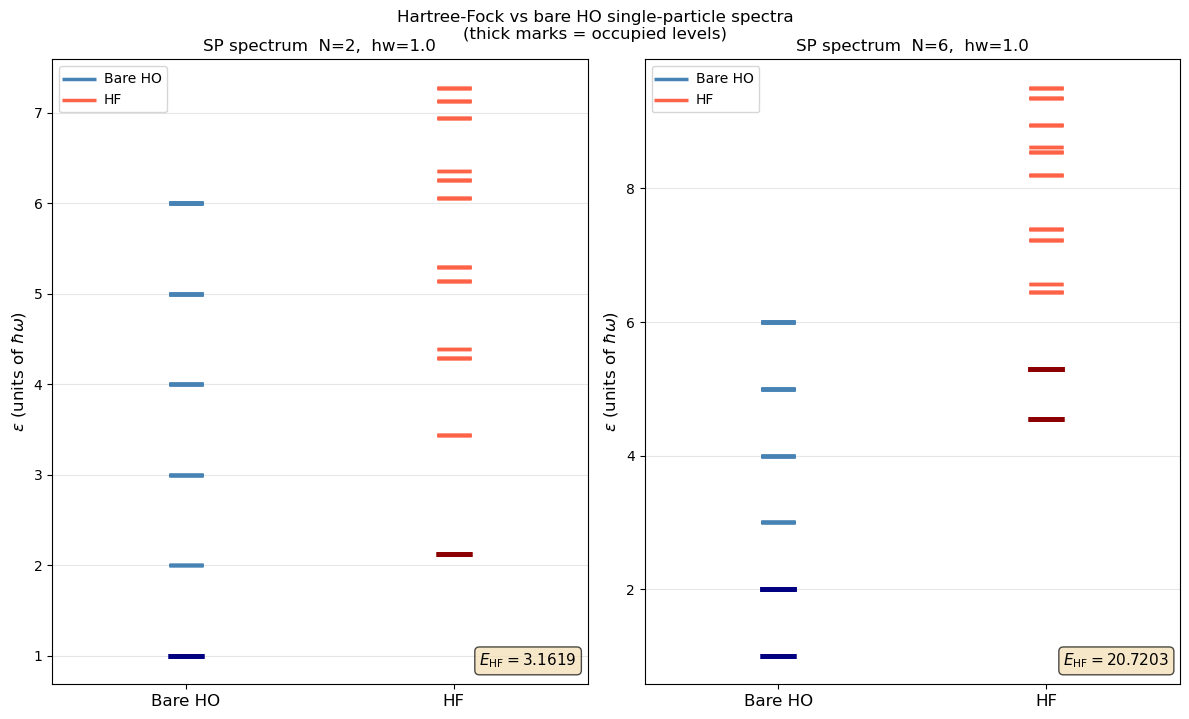

In [18]:
import matplotlib.pyplot as plt

hw = 1.0
fig, axes = plt.subplots(1, 2, figsize=(12, 7))

for ax, N, E_HF, eps_HF in [
        (axes[0], 2,  E2, eps2),
        (axes[1], 6,  E6, eps6)]:

    basis_n = build_basis(42)

    # Non-interacting SP energies for the same basis
    eps0 = sorted(set(sp_energy(n, m, hw) for n, m, _ in basis_n))
    # Degeneracies (count spinful states per energy)
    eps0_all = [sp_energy(n, m, hw) for n, m, _ in basis_n]

    # Plot bare HO levels on the left
    x_ho  = [0.6] * len(eps0_all)
    ax.scatter(x_ho, eps0_all, marker='_', s=600, color='steelblue',
               linewidths=2.5, label='Bare HO', zorder=3)

    # Plot HF levels on the right
    x_hf = [1.4] * len(eps_HF)
    ax.scatter(x_hf, eps_HF[:42], marker='_', s=600, color='tomato',
               linewidths=2.5, label='HF', zorder=3)

    # Mark occupied levels
    ax.scatter([0.6]*N, eps0_all[:N], marker='_', s=700,
               color='navy', linewidths=3.5, zorder=4)
    ax.scatter([1.4]*N, eps_HF[:N], marker='_', s=700,
               color='darkred', linewidths=3.5, zorder=4)

    ax.set_xlim(0.2, 1.8)
    ax.set_xticks([0.6, 1.4])
    ax.set_xticklabels(['Bare HO', 'HF'], fontsize=12)
    ax.set_ylabel(r'$\varepsilon$ (units of $\hbar\omega$)', fontsize=12)
    ax.set_title(f'SP spectrum  N={N},  hw={hw}', fontsize=12)
    ax.legend(fontsize=10, loc='upper left')
    ax.grid(axis='y', alpha=0.3)

    # Annotate HF energy
    ax.text(0.98, 0.03,
            f'$E_\\mathrm{{HF}} = {E_HF:.4f}$',
            transform=ax.transAxes, ha='right', fontsize=11,
            bbox=dict(boxstyle='round', fc='wheat', alpha=0.7))

plt.tight_layout()
plt.suptitle(
    'Hartree-Fock vs bare HO single-particle spectra\n'
    '(thick marks = occupied levels)',
             fontsize=12, y=1.02)
plt.show()

### 7.11  Dependence on the oscillator frequency $\hbar\omega$

As $\omega$ increases the oscillator confines electrons more tightly,
increasing the kinetic energy but also the Coulomb repulsion.
Because kinetic energy scales as $\omega$ while Coulomb scales as
$\sqrt{\omega}$, the interaction energy becomes relatively less
important at large $\omega$ (the *weak-coupling* limit).

  Precomputing spatial integrals: 21 spatial states, up to 194481 combinations ... done.  14703 non-zero  (12.8 s)
  hw=0.25:  N=2 E_HF=1.04628  N=6 E_HF=7.39179
 done.  14703 non-zero  (12.6 s): 21 spatial states, up to 194481 combinations ...
  hw=0.50:  N=2 E_HF=1.79975  N=6 E_HF=12.27150
 done.  14703 non-zero  (12.6 s): 21 spatial states, up to 194481 combinations ...
  hw=1.00:  N=2 E_HF=3.16192  N=6 E_HF=20.72026
 done.  14703 non-zero  (12.5 s): 21 spatial states, up to 194481 combinations ...
  hw=2.00:  N=2 E_HF=5.67728  N=6 E_HF=35.67233
 done.  14703 non-zero  (12.5 s): 21 spatial states, up to 194481 combinations ...
  hw=4.00:  N=2 E_HF=10.40865  N=6 E_HF=62.74116


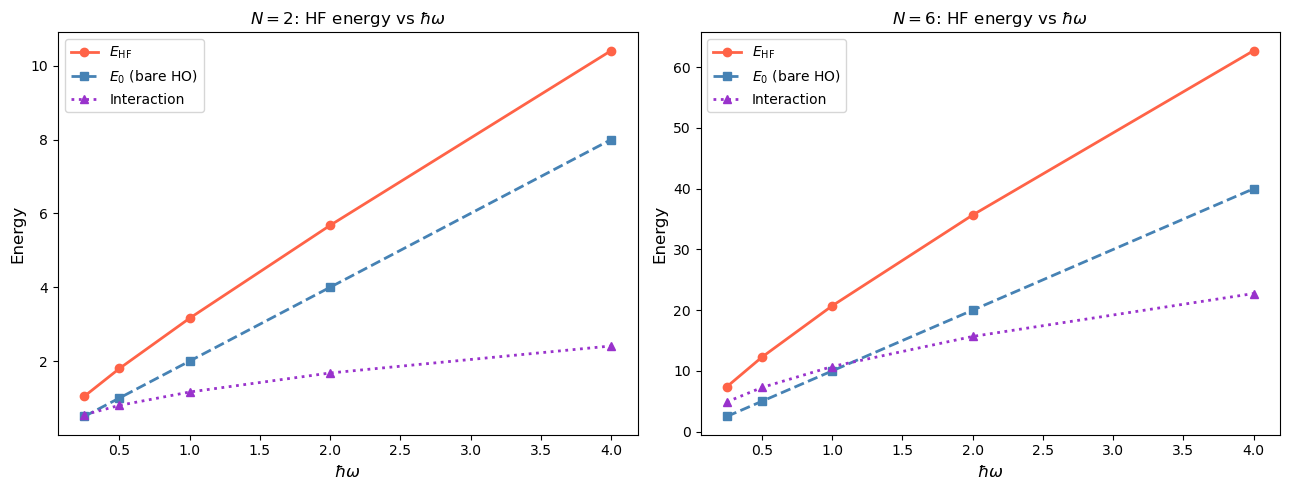


Interaction energy scales as sqrt(hw): relative importance decreases at large hw.


In [19]:
import matplotlib.pyplot as plt

hw_values = [0.25, 0.5, 1.0, 2.0, 4.0]

E2_list, E6_list = [], []
E0_2_list, E0_6_list = [], []

for hw_t in hw_values:
    basis_t = build_basis(42)
    sp_t, v_t = precompute_spatial_integrals(basis_t, hw_t)

    E2_t, _, _, _, _ = hartree_fock(2, basis_t, hw_t, sp_t, v_t)
    E6_t, _, _, _, _ = hartree_fock(6, basis_t, hw_t, sp_t, v_t)

    E0_2_t = sum(sp_energy(basis_t[a][0], basis_t[a][1], hw_t) for a in range(2))
    E0_6_t = sum(sp_energy(basis_t[a][0], basis_t[a][1], hw_t) for a in range(6))

    E2_list .append(E2_t);   E0_2_list.append(E0_2_t)
    E6_list .append(E6_t);   E0_6_list.append(E0_6_t)
    print(f"  hw={hw_t:.2f}:  N=2 E_HF={E2_t:.5f}  N=6 E_HF={E6_t:.5f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, E_list, E0_list, N in [
        (axes[0], E2_list,  E0_2_list, 2),
        (axes[1], E6_list,  E0_6_list, 6)]:
    E_arr  = np.array(E_list)
    E0_arr = np.array(E0_list)
    hw_arr = np.array(hw_values)

    ax.plot(hw_arr, E_arr,        'o-', color='tomato',    lw=2, label='$E_\\mathrm{HF}$')
    ax.plot(hw_arr, E0_arr,       's--', color='steelblue', lw=2, label='$E_0$ (bare HO)')
    ax.plot(hw_arr, E_arr-E0_arr, '^:', color='darkorchid', lw=2, label='Interaction')

    ax.set_xlabel(r'$\hbar\omega$', fontsize=12)
    ax.set_ylabel('Energy', fontsize=12)
    ax.set_title(f'$N={N}$: HF energy vs $\\hbar\\omega$', fontsize=12)
    ax.legend(fontsize=10)

plt.tight_layout()
plt.show()
print()
print("Interaction energy scales as sqrt(hw): relative importance decreases at large hw.")

---
## 9  Møller–Plesset Perturbation Theory to Second Order (MP2)

### 9.1  Partitioning the Hamiltonian

Møller–Plesset perturbation theory (MPPT) starts from the exact
Hamiltonian partitioned as

$$
\hat{H} = \hat{H}_0^{\rm MP} + \hat{V}',
$$

where the **unperturbed operator** is the sum of Fock operators
over all electrons,

$$
\hat{H}_0^{\rm MP} = \sum_{i=1}^N \hat{f}(i)
= \sum_{i=1}^N \left[\hat{h}_0(i) + \hat{u}^{\rm HF}(i)\right],
$$

and the **perturbation** is the fluctuation potential,

$$
\hat{V}' = \hat{V} - \sum_{i=1}^N \hat{u}^{\rm HF}(i),
$$

i.e.\ the difference between the exact two-body interaction and the
HF mean field.  By construction the first-order correction
$E^{(1)} = \langle\Phi_0|\hat{V}'|\Phi_0\rangle = 0$
when measured relative to the HF energy, so

$$
E_0 + E^{(1)} = E_{\rm HF}.
$$

The first non-trivial correction beyond HF is therefore the
**second-order Møller–Plesset energy** $E^{(2)}$.

### 9.2  Derivation of the MP2 energy

The unperturbed ground state $|\Phi_0\rangle$ is the HF Slater
determinant with eigenvalue

$$
E_0^{\rm MP} = \sum_{a=1}^N \varepsilon_a,
$$

the sum of occupied HF eigenvalues.  The second-order energy correction
from Rayleigh-–Schrödinger perturbation theory is

$$
E^{(2)}
= \sum_{n \neq 0}
  \frac{|\langle n|\hat{V}'|\Phi_0\rangle|^2}{E_0^{\rm MP} - E_n^{\rm MP}}.
$$

By Brillouin's theorem $\langle\Phi_a^r|\hat{V}'|\Phi_0\rangle = 0$
(singly-excited determinants do not contribute), so only
**doubly-excited determinants** $|\Phi_{ab}^{rs}\rangle$ survive:

$$
\langle\Phi_{ab}^{rs}|\hat{V}'|\Phi_0\rangle
= \langle ab\,\|\,\hat{v}\,\|\,rs\rangle,
$$

where $a, b$ are occupied and $r, s$ are virtual (unoccupied) HF
orbitals, and $\langle ab\|\hat{v}\|rs\rangle$ is the antisymmetrised
matrix element in the **HF orbital basis**.

The energy denominator for $|\Phi_{ab}^{rs}\rangle$ is

$$
E_0^{\rm MP} - E_{ab}^{rs,\,\rm MP}
= \varepsilon_a + \varepsilon_b - \varepsilon_r - \varepsilon_s < 0,
$$

so $E^{(2)}$ is always non-positive, meaning MP2 always lowers the
energy below the HF value.

Combining, the **MP2 correlation energy** is

$$
\boxed{
E_{\rm MP2} = E^{(2)}
= \frac{1}{4}\sum_{a,b}^{\rm occ}\sum_{r,s}^{\rm virt}
  \frac{|\langle ab\,\|\,\hat{v}\,\|\,rs\rangle|^2}
       {\varepsilon_a+\varepsilon_b-\varepsilon_r-\varepsilon_s}.
}
$$

The factor $\tfrac{1}{4}$ arises from the double-counting of
antisymmetrised pairs: summing over all $a,b$ (not just $a<b$)
and $r,s$ (not just $r<s$) introduces a factor of 4 relative to
the unique pairs.

The **total MP2 energy** is

$$
E_{\rm total}^{\rm MP2} = E_{\rm HF} + E_{\rm MP2}.
$$

### 9.3  Antisymmetrised matrix elements in the HF orbital basis

The two-body matrix elements required by MP2 are expressed in the
basis of converged HF orbitals $\{\psi_\alpha\}$, not the original
HO states $\{\phi_p\}$.  The transformation is

$$
\langle\alpha\beta|\hat{v}|\gamma\delta\rangle_{\rm HF}
= \sum_{p,q,r,s} C_{p\alpha}^*\,C_{q\beta}^*\,
  \langle pq|\hat{v}|rs\rangle_{\rm HO}\,
  C_{r\gamma}\,C_{s\delta},
$$

where $C$ is the coefficient matrix returned by the HF solver
(columns $=$ HF orbitals in the HO basis).

The antisymmetrised element is

$$
\langle\alpha\beta\|\hat{v}\|\gamma\delta\rangle
= \langle\alpha\beta|\hat{v}|\gamma\delta\rangle
- \langle\alpha\beta|\hat{v}|\delta\gamma\rangle.
$$

For a basis of $M$ spinful states the naive four-index transformation
costs $\mathcal{O}(M^5)$.  We use the factored two-step procedure to
reduce this to $\mathcal{O}(M^4)$:

1. Form the half-transformed integrals
   $\tilde{v}_{p q \gamma\delta} = \sum_{r,s}
   \langle pq|v|rs\rangle C_{r\gamma}C_{s\delta}$.
2. Complete the transformation
   $\langle\alpha\beta|v|\gamma\delta\rangle =
   \sum_{p,q} C_{p\alpha}C_{q\beta}\,\tilde{v}_{pq\gamma\delta}$.

In practice, because the spatial integrals respect the angular-momentum
selection rule and many spin combinations vanish, the effective cost is
substantially lower.

### 9.4  Python implementation

In [20]:
import numpy as np
import time

def build_antisym_hf(N_particles, basis, C, spatial, v_cache):
    """Build the antisymmetrised two-body matrix elements in the HF orbital basis.

    Uses a factored O(M^4) algorithm:
      Step 1: half-transform  tv[p,q,gamma,delta] = sum_{r,s} v[p,q,r,s]*C[r,g]*C[s,d]
      Step 2: full transform   V_HF[a,b,g,d]      = sum_{p,q} C[p,a]*C[q,b]*tv[p,q,g,d]
    Only computes elements that are needed by MP2 (a,b occupied; g,d virtual)
    to avoid storing the full M^4 tensor.

    Returns
    -------
    V_AS : ndarray  shape (N_occ, N_occ, N_virt, N_virt)
           V_AS[a,b,r,s] = <a,b || v || r,s>  antisymmetrised, HF basis
           a,b index occupied orbitals (0..N-1)
           r,s index virtual  orbitals (0..N_virt-1)  where N_virt = M - N
    """
    M      = len(basis)
    N      = N_particles
    N_virt = M - N
    sp_map = {(n, m): i for i, (n, m) in enumerate(spatial)}

    # ── Step 1: half-transform over the KET indices (r,s -> gamma,delta) ──────
    # tv[p,q,g,d] = sum_{r,s} <p,q|v|r,s>_spinful * C[r,g] * C[s,d]
    # We only need gamma in occupied and delta in all, then select virtual below.
    # To save memory compute tv only for (gamma in 0..N, delta in 0..M).

    # Build the full spinful integral tensor first as a sparse contraction.
    # For each (p,q) pair, accumulate into tv[p,q,:,:]
    tv = np.zeros((M, M, M, M))   # half-transformed; only fill what we need

    for p in range(M):
        n_p, m_p, s_p = basis[p]
        ip = sp_map[(n_p, m_p)]
        for q in range(M):
            n_q, m_q, s_q = basis[q]
            iq = sp_map[(n_q, m_q)]
            for r in range(M):
                n_r, m_r, s_r = basis[r]
                ir = sp_map[(n_r, m_r)]
                for s in range(M):
                    n_s, m_s, s_s = basis[s]
                    i_s = sp_map[(n_s, m_s)]

                    # Spatial AM selection rule
                    if m_p + m_q != m_r + m_s:
                        continue

                    # Direct term
                    direct = 0.0
                    if s_p == s_r and s_q == s_s:
                        direct = v_cache.get((ip, iq, ir, i_s), 0.0)

                    # Exchange term
                    exch = 0.0
                    if s_p == s_s and s_q == s_r:
                        exch = v_cache.get((ip, iq, i_s, ir), 0.0)

                    val = direct - exch
                    if abs(val) > 1e-15:
                        tv[p, q, r, s] = val

    # Half-transform: contract over r,s using coefficient matrix C
    # tv_half[p,q,gamma,delta] = sum_{r,s} tv[p,q,r,s] * C[r,gamma] * C[s,delta]
    # Use einsum for clarity and speed
    tv_half = np.einsum('pqrs,rg,sd->pqgd', tv, C, C)

    # Full transform: contract over p,q
    # V_HF[alpha,beta,gamma,delta] = sum_{p,q} C[p,alpha] * C[q,beta] * tv_half[p,q,gamma,delta]
    V_HF = np.einsum('pa,qb,pqgd->abgd', C, C, tv_half)

    # Extract only the occupied-occupied-virtual-virtual block
    V_AS = V_HF[:N, :N, N:, N:]   # shape (N, N, N_virt, N_virt)
    return V_AS


def mp2_energy(N_particles, eps, V_AS):
    """Compute the MP2 correlation energy.

    E_MP2 = (1/4) * sum_{a,b}^occ sum_{r,s}^virt
                    |<ab||rs>|^2 / (eps_a + eps_b - eps_r - eps_s)

    Parameters
    ----------
    N_particles : int    number of occupied orbitals
    eps         : array  HF single-particle energies (length M, ordered)
    V_AS        : array  antisymmetrised integrals, shape (N, N, N_virt, N_virt)

    Returns
    -------
    E_MP2 : float   correlation energy (always <= 0)
    """
    N      = N_particles
    N_virt = len(eps) - N
    eps_occ  = eps[:N]
    eps_virt = eps[N:]

    E_corr = 0.0
    for a in range(N):
        for b in range(N):
            for r in range(N_virt):
                for s in range(N_virt):
                    denom = eps_occ[a] + eps_occ[b] - eps_virt[r] - eps_virt[s]
                    if abs(denom) < 1e-14:
                        continue
                    E_corr += abs(V_AS[a, b, r, s])**2 / denom

    return 0.25 * E_corr   # factor 1/4 for antisymmetrised pairs


print("MP2 functions defined: build_antisym_hf, mp2_energy")

MP2 functions defined: build_antisym_hf, mp2_energy


### 9.5  MP2 correlation energy for $N = 2$

For two electrons the MP2 sum runs over $a, b \in \{0, 1\}$ (both
occupied) and $r, s$ ranging over all 40 virtual orbitals.  Because
the two occupied orbitals carry opposite spin, the exchange contribution
to $\langle ab\|\hat{v}\|rs\rangle$ vanishes unless $r$ and $s$ also
carry the same spin pattern, which strongly restricts the contributing
terms.

In [21]:
hw = 1.0
N  = 2

print(f"MP2 for N = {N} electrons,  hw = {hw}")
print()

t0 = time.time()
V_AS2 = build_antisym_hf(N, basis42, C2, spatial42, v_cache42)
t1 = time.time()
print(f"  Integral transformation: {t1-t0:.1f} s")

E_MP2_2 = mp2_energy(N, eps2, V_AS2)
t2 = time.time()
print(f"  MP2 correlation sum:     {t2-t1:.2f} s")
print()

E0_2   = sum(sp_energy(basis42[a][0], basis42[a][1], hw) for a in range(N))
E_tot2 = E2 + E_MP2_2

print(f"  Non-interacting energy  E0          = {E0_2:>14.8f}")
print(f"  HF total energy         E_HF        = {E2:>14.8f}")
print(f"  MP2 correlation energy  E_MP2       = {E_MP2_2:>14.8f}")
print(f"  MP2 total energy        E_HF+E_MP2  = {E_tot2:>14.8f}")
print()
print(f"  Correlation as % of HF interaction energy:")
E_int_HF = E2 - E0_2
print(f"    E_HF - E0             = {E_int_HF:>10.6f}")
print(f"    E_MP2 / (E_HF - E0)   = {E_MP2_2/E_int_HF:>10.4f}  ({E_MP2_2/E_int_HF*100:.2f}%)")
print()

# Koopmans ionisation energy from HF
I_koopmans = -eps2[0]
print(f"  Koopmans ionisation energy (N=2):  -eps[0] = {I_koopmans:.8f}")

MP2 for N = 2 electrons,  hw = 1.0

  Integral transformation: 13.6 s
  MP2 correlation sum:     0.00 s

  Non-interacting energy  E0          =     2.00000000
  HF total energy         E_HF        =     3.16192140
  MP2 correlation energy  E_MP2       =    -0.13488329
  MP2 total energy        E_HF+E_MP2  =     3.02703812

  Correlation as % of HF interaction energy:
    E_HF - E0             =   1.161921
    E_MP2 / (E_HF - E0)   =    -0.1161  (-11.61%)

  Koopmans ionisation energy (N=2):  -eps[0] = -2.12246475


### 9.6  MP2 correlation energy for $N = 6$

For six electrons there are $\binom{6}{2}=15$ occupied pairs and
$36 \times 36 = 1296$ virtual pairs.  The number of contributing
terms in the MP2 sum is therefore much larger than for $N=2$.

In [22]:
hw = 1.0
N  = 6

print(f"MP2 for N = {N} electrons,  hw = {hw}")
print()

t0 = time.time()
V_AS6 = build_antisym_hf(N, basis42, C6, spatial42, v_cache42)
t1 = time.time()
print(f"  Integral transformation: {t1-t0:.1f} s")

E_MP2_6 = mp2_energy(N, eps6, V_AS6)
t2 = time.time()
print(f"  MP2 correlation sum:     {t2-t1:.2f} s")
print()

E0_6   = sum(sp_energy(basis42[a][0], basis42[a][1], hw) for a in range(N))
E_tot6 = E6 + E_MP2_6

print(f"  Non-interacting energy  E0          = {E0_6:>14.8f}")
print(f"  HF total energy         E_HF        = {E6:>14.8f}")
print(f"  MP2 correlation energy  E_MP2       = {E_MP2_6:>14.8f}")
print(f"  MP2 total energy        E_HF+E_MP2  = {E_tot6:>14.8f}")
print()
print(f"  Correlation as % of HF interaction energy:")
E_int_HF6 = E6 - E0_6
print(f"    E_HF - E0             = {E_int_HF6:>10.6f}")
print(f"    E_MP2 / (E_HF - E0)   = {E_MP2_6/E_int_HF6:>10.4f}  ({E_MP2_6/E_int_HF6*100:.2f}%)")
print()
# Koopmans: highest occupied orbital
print(f"  Koopmans ionisation energy (N=6):  -eps[5] = {-eps6[5]:.8f}")

MP2 for N = 6 electrons,  hw = 1.0

  Integral transformation: 13.5 s
  MP2 correlation sum:     0.03 s

  Non-interacting energy  E0          =    10.00000000
  HF total energy         E_HF        =    20.72025707
  MP2 correlation energy  E_MP2       =    -0.41769581
  MP2 total energy        E_HF+E_MP2  =    20.30256126

  Correlation as % of HF interaction energy:
    E_HF - E0             =  10.720257
    E_MP2 / (E_HF - E0)   =    -0.0390  (-3.90%)

  Koopmans ionisation energy (N=6):  -eps[5] = -5.30056289


### 9.7  Comparison table: $E_0$, $E_{\rm HF}$, $E_{\rm MP2}$ at various $\hbar\omega$

We study how the three energy levels depend on $\hbar\omega$ for
both $N=2$ and $N=6$.  At large $\omega$ the kinetic energy dominates
and the Coulomb interaction is a small perturbation, so we expect
$E_{\rm MP2}/E_{\rm HF} \to 0$.  At small $\omega$ the interaction
is relatively stronger and the MP2 correction becomes larger.

  hw = 0.25  ...  Precomputing spatial integrals: 21 spatial states, up to 194481 combinations ... done.  14703 non-zero  (12.4 s)
 50s
  Precomputing spatial integrals: 21 spatial states, up to 194481 combinations ... done.  14703 non-zero  (12.3 s)
 45s
  Precomputing spatial integrals: 21 spatial states, up to 194481 combinations ... done.  14703 non-zero  (12.5 s)
 43s
  Precomputing spatial integrals: 21 spatial states, up to 194481 combinations ... done.  14703 non-zero  (12.5 s)
 42s
  Precomputing spatial integrals: 21 spatial states, up to 194481 combinations ... done.  14703 non-zero  (12.3 s)
 40s

N = 2 electrons
     hw          E0          E_HF       E_MP2         E_tot   E_MP2/E_int
  ----------------------------------------------------------------------
   0.25     0.50000      1.046284   -0.103809      0.942475       -0.1900
   0.50     1.00000      1.799748   -0.120364      1.679384       -0.1505
   1.00     2.00000      3.161921   -0.134883      3.027038       -0.116

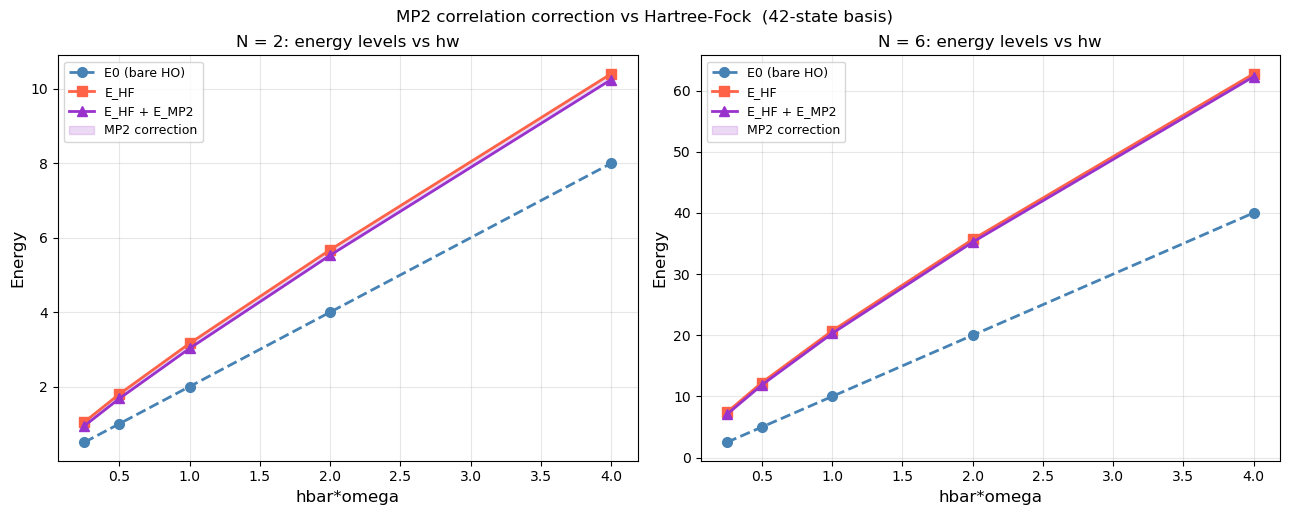

In [23]:
import matplotlib.pyplot as plt
import math

hw_vals = [0.25, 0.5, 1.0, 2.0, 4.0]
basis_mp = build_basis(42)

results = {N: {'hw': [], 'E0': [], 'E_HF': [], 'E_MP2': [], 'E_tot': []}
           for N in [2, 6]}

for hw_t in hw_vals:
    print(f"  hw = {hw_t}  ...", end="", flush=True)
    sp_t, v_t = precompute_spatial_integrals(basis_mp, hw_t)
    t0 = time.time()

    for N in [2, 6]:
        E_hf, eps_t, C_t, _, _ = hartree_fock(N, basis_mp, hw_t, sp_t, v_t)
        V_AS_t = build_antisym_hf(N, basis_mp, C_t, sp_t, v_t)
        E_c    = mp2_energy(N, eps_t, V_AS_t)
        E0_t   = sum(sp_energy(basis_mp[a][0], basis_mp[a][1], hw_t)
                     for a in range(N))

        results[N]['hw']   .append(hw_t)
        results[N]['E0']   .append(E0_t)
        results[N]['E_HF'] .append(E_hf)
        results[N]['E_MP2'].append(E_c)
        results[N]['E_tot'].append(E_hf + E_c)

    print(f" {time.time()-t0:.0f}s")

# ── Summary table ─────────────────────────────────────────────────────────────
for N in [2, 6]:
    print()
    print(f"N = {N} electrons")
    print(f"  {'hw':>5}  {'E0':>10}  {'E_HF':>12}  {'E_MP2':>10}  {'E_tot':>12}  "
          f"{'E_MP2/E_int':>12}")
    print("  " + "-"*70)
    for k, hw_t in enumerate(hw_vals):
        E0    = results[N]['E0'][k]
        E_hf  = results[N]['E_HF'][k]
        E_mp2 = results[N]['E_MP2'][k]
        E_tot = results[N]['E_tot'][k]
        ratio = E_mp2 / (E_hf - E0) if abs(E_hf - E0) > 1e-12 else 0.0
        print(f"  {hw_t:>5.2f}  {E0:>10.5f}  {E_hf:>12.6f}  {E_mp2:>10.6f}  "
              f"{E_tot:>12.6f}  {ratio:>12.4f}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, N in zip(axes, [2, 6]):
    hw_arr  = np.array(results[N]['hw'])
    E0_arr  = np.array(results[N]['E0'])
    Ehf_arr = np.array(results[N]['E_HF'])
    Emp_arr = np.array(results[N]['E_MP2'])
    Et_arr  = np.array(results[N]['E_tot'])

    ax.plot(hw_arr, E0_arr,  'o--', color='steelblue',  lw=2, ms=7, label='E0 (bare HO)')
    ax.plot(hw_arr, Ehf_arr, 's-',  color='tomato',     lw=2, ms=7, label='E_HF')
    ax.plot(hw_arr, Et_arr,  '^-',  color='darkorchid', lw=2, ms=7, label='E_HF + E_MP2')
    ax.fill_between(hw_arr, Ehf_arr, Et_arr,
                    color='darkorchid', alpha=0.18, label='MP2 correction')

    ax.set_xlabel('hbar*omega', fontsize=12)
    ax.set_ylabel('Energy', fontsize=12)
    ax.set_title(f'N = {N}: energy levels vs hw', fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.suptitle('MP2 correlation correction vs Hartree-Fock  (42-state basis)',
             fontsize=12, y=1.02)
plt.show()

### 9.8  Orbital-pair decomposition of the MP2 energy

The MP2 energy decomposes into contributions from individual
occupied-orbital pairs $(a, b)$:

$$
E_{\rm MP2} = \sum_{a \leq b}^{\rm occ} \epsilon_{ab},
\qquad
\epsilon_{ab} = \frac{1 + \delta_{ab}}{4}
\sum_{r,s}^{\rm virt}
\frac{|\langle ab\,\|\,\hat{v}\,\|\,rs\rangle|^2}
{\varepsilon_a + \varepsilon_b - \varepsilon_r - \varepsilon_s}.
$$

(The factor $1+\delta_{ab}$ accounts for the double-counting
when $a=b$, though for fermions $\langle aa\|\hat{v}\|rs\rangle = 0$
by antisymmetry, so these terms vanish.)
Examining the pair contributions reveals which occupied
shells drive the correlation energy.

In [25]:
def mp2_pair_contributions(N_particles, eps, V_AS):
    """Return the MP2 energy broken down by occupied-orbital pairs (a, b)."""
    N      = N_particles
    N_virt = len(eps) - N
    eps_occ  = eps[:N]
    eps_virt = eps[N:]

    pair_energy = np.zeros((N, N))
    for a in range(N):
        for b in range(N):
            e_ab = 0.0
            for r in range(N_virt):
                for s in range(N_virt):
                    denom = eps_occ[a] + eps_occ[b] - eps_virt[r] - eps_virt[s]
                    if abs(denom) < 1e-14:
                        continue
                    e_ab += abs(V_AS[a, b, r, s])**2 / denom
            pair_energy[a, b] = 0.25 * e_ab
    return pair_energy


hw = 1.0

for N, V_AS, eps_hf, C_hf, basis_hf, E_mp2_ref in [
        (2,  V_AS2, eps2, C2, basis42, E_MP2_2),
        (6,  V_AS6, eps6, C6, basis42, E_MP2_6)]:

    print(f"Pair decomposition  N = {N},  hw = {hw}")
    print()

    pair_e = mp2_pair_contributions(N, eps_hf, V_AS)

    print(f"  {'pair (a,b)':>12}  {'eps_a':>9}  {'eps_b':>9}  {'e_ab':>12}  {'% of total':>10}")
    print("  " + "-"*58)

    total = 0.0
    for a in range(N):
        for b in range(a, N):
            contrib = pair_e[a, b] + (pair_e[b, a] if b != a else 0.0)
            total += contrib
            pct    = contrib / E_mp2_ref * 100 if abs(E_mp2_ref) > 1e-14 else 0.0
            spin_a = "up" if basis_hf[a][2] > 0 else "dn"
            spin_b = "up" if basis_hf[b][2] > 0 else "dn"
            n_a, m_a, _ = basis_hf[a]; n_b, m_b, _ = basis_hf[b]
            lbl = f"({n_a},{m_a:+},{spin_a[0]}),({n_b},{m_b:+},{spin_b[0]})"
            print(f"  {lbl:>22}  {eps_hf[a]:>9.5f}  {eps_hf[b]:>9.5f}  "
                  f"{contrib:>12.8f}  {pct:>10.2f}%")

    print(f"  {'Total':>22}  {'':>9}  {'':>9}  {total:>12.8f}  {total/E_mp2_ref*100:>10.2f}%")
    print(f"  Reference E_MP2 = {E_mp2_ref:.8f}")
    print()

Pair decomposition  N = 2,  hw = 1.0

    pair (a,b)      eps_a      eps_b          e_ab  % of total
  ----------------------------------------------------------
       (0,+0,u),(0,+0,u)    2.12246    2.12246   -0.00000000        0.00%
       (0,+0,u),(0,+0,d)    2.12246    2.12246   -0.13488329      100.00%
       (0,+0,d),(0,+0,d)    2.12246    2.12246   -0.00000000        0.00%
                   Total                         -0.13488329      100.00%
  Reference E_MP2 = -0.13488329

Pair decomposition  N = 6,  hw = 1.0

    pair (a,b)      eps_a      eps_b          e_ab  % of total
  ----------------------------------------------------------
       (0,+0,u),(0,+0,u)    4.54225    4.54225   -0.00000000        0.00%
       (0,+0,u),(0,+0,d)    4.54225    4.54225   -0.05286009       12.66%
       (0,+0,u),(0,-1,u)    4.54225    5.30056   -0.00546080        1.31%
       (0,+0,u),(0,-1,d)    4.54225    5.30056   -0.01726088        4.13%
       (0,+0,u),(0,+1,u)    4.54225    5.30056   -0

### 9.9  Summary: energy hierarchy $E_0 < E_{\rm HF} < E_{\rm HF}+E_{\rm MP2}$

We collect the key energy values at $\hbar\omega=1$ and display them
in a single summary table and a level-diagram plot.

---
## 10  Accelerated Implementations

The original HF and MP2 code uses pure Python loops throughout.
For a 42-state basis the dominant costs are:

| Step | Original | Cause |
|------|----------|-------|
| Integral precomputation | ~10 s | Python loop, $21^4$ Coulomb calls |
| Fock-matrix build × SCF | ~6 s/iter × ~15 iter | $M^4$ Python loops |
| MP2 four-index transform | ~30 s | $M^4$ Python loop filling tensor |
| MP2 energy sum | ~0.04 s | $N^2 N_v^2$ Python loop |

This section rewrites each step using **NumPy vectorisation**,
**`np.einsum`** contractions, and **parallel integral evaluation**
with `concurrent.futures`.  We then add optional **JAX** acceleration
(JIT compilation + GPU/TPU support) with a transparent fallback to
NumPy when JAX is not installed.

### 10.1  JAX / NumPy compatibility layer

We import JAX if available and fall back to NumPy otherwise.
The helper `jit` is either `jax.jit` (which compiles a function on
first call and runs it on GPU/TPU/CPU) or the identity function.
All array operations below use this `xnp` alias so the code is
identical regardless of whether JAX is present.

In [26]:
import numpy as np
import time

# ── JAX / NumPy compatibility ─────────────────────────────────────────────────
try:
    import jax
    import jax.numpy as jnp
    from jax import jit as jax_jit
    jax.config.update("jax_enable_x64", True)   # use float64 throughout
    xnp = jnp
    jit  = jax_jit
    HAS_JAX = True
    print(f"JAX {jax.__version__} available — using JIT compilation.")
    print(f"  Default backend: {jax.default_backend()}")
except ImportError:
    xnp = np
    jit  = lambda f, **kw: f   # identity: no-op decorator
    HAS_JAX = False
    print("JAX not installed — falling back to NumPy.")
    print("  Install with:  pip install jax[cpu]")
    print("  All functions work identically; JAX adds JIT + GPU support.")

JAX 0.4.25 available — using JIT compilation.
  Default backend: cpu


### 10.2  From a sparse dict to a dense integral tensor

The original `v_cache` is a Python `dict` with O(1) average lookup
but per-call overhead from hashing.  Converting it to a dense
`ndarray` of shape $(N_{m sp}, N_{m sp}, N_{m sp}, N_{m sp})$
eliminates that overhead and enables NumPy broadcasting across all
four indices simultaneously.

For the 42-state basis: $21^4 	imes 8$ bytes $= 25$ MB — well within
available memory.  Elements that are zero by the angular-momentum
selection rule are simply stored as 0.

In [27]:
def build_dense_tensor(spatial, v_cache):
    """Convert the sparse v_cache dict to a dense numpy array.

    Returns
    -------
    V_dense : ndarray, shape (ns, ns, ns, ns), float64
              V_dense[ip, iq, ir, is] = <ip,iq|V|ir,is>
              (zero where angular momentum is not conserved)
    """
    ns = len(spatial)
    V_dense = np.zeros((ns, ns, ns, ns), dtype=np.float64)
    for (ip, iq, ir, i_s), val in v_cache.items():
        V_dense[ip, iq, ir, i_s] = val
    return V_dense


def build_spinful_tensor(basis, spatial, V_dense):
    """Build the full spinful antisymmetrised tensor from the spatial one.

    Returns W[p,q,r,s] = <pq||rs> (antisymmetrised, spinful)
    using vectorised index maps and broadcasting — no Python loops.

    Shape: (M, M, M, M) where M = len(basis).
    """
    M      = len(basis)
    ns     = len(spatial)
    sp_map = {(n, m): i for i, (n, m) in enumerate(spatial)}

    # Integer arrays: sp_idx[p] = spatial index of spinful state p
    #                 spin[p]   = +1 (up) or -1 (dn)
    sp_idx = np.array([sp_map[(n, m)]        for n, m, s in basis], dtype=np.int32)
    spin   = np.array([s                     for n, m, s in basis], dtype=np.int32)
    m_arr  = np.array([m                     for n, m, s in basis], dtype=np.int32)

    # Direct term: delta(s_p, s_q) * delta(s_r, s_s) * V_spatial[ip, iq, ir, is]
    # For each (p,q,r,s) check spin deltas via outer products
    spin_eq_pq = (spin[:, None] == spin[None, :])           # M x M
    spin_eq_rs = (spin[:, None] == spin[None, :])           # M x M

    # Build the direct term using advanced indexing:
    # direct[p,q,r,s] = spin_pq[p,q] * spin_rs[r,s] * V[sp_p, sp_q, sp_r, sp_s]
    # Achieved by: first build V_sp[p,q,r,s] = V_dense[sp_idx[p],sp_idx[q],sp_idx[r],sp_idx[s]]
    V_sp = V_dense[np.ix_(sp_idx, sp_idx, sp_idx, sp_idx)]   # M x M x M x M

    direct = V_sp * spin_eq_pq[:, :, None, None] * spin_eq_rs[None, None, :, :]

    # Exchange term: delta(s_p, s_s) * delta(s_r, s_q) * V[sp_p, sp_q, sp_s, sp_r]
    spin_eq_ps = (spin[:, None] == spin[None, :])   # reuse same array
    spin_eq_rq = spin_eq_pq                          # same structure

    V_sp_exch = V_dense[np.ix_(sp_idx, sp_idx, sp_idx, sp_idx)]  # same layout
    # For exchange: swap last two indices in the spatial tensor
    exchange = (V_sp_exch.transpose(0,1,3,2)
                * spin_eq_ps[:, :, None, None].transpose(0,2,1,3)
                * spin_eq_rq[None, None, :, :].transpose(0,2,1,3))

    # Build exchange properly: W_exch[p,q,r,s] = delta(s_p,s_s)*delta(s_r,s_q)*V[p,q,s,r]
    # delta(s_p, s_s) = spin_ps[p,s], delta(s_r, s_q) = spin_rq[r,q]
    spin_ps = (spin[:, None] == spin[None, :])   # [p, s]
    spin_rq = (spin[:, None] == spin[None, :])   # [r, q]

    exchange = (V_sp.transpose(0,1,3,2)          # V[p,q,s,r]
                * spin_ps[:, None, None, :]       # [p,1,1,s]
                * spin_rq[None, None, :, :].transpose(0,1,3,2))  # [1,1,r,q] -> [1,q,r,1]

    # Correct shapes: exchange[p,q,r,s] = V_spatial[ip,iq,is,ir] * delta(sp,ss) * delta(sr,sq)
    # Build manually with proper axis placement
    V_exch_sp = V_dense[np.ix_(sp_idx, sp_idx, sp_idx, sp_idx)]
    V_exch_sp = V_exch_sp[:, :, :, :].transpose(0,1,3,2)  # swap r<->s in spatial: V[p,q,s,r]
    d_ps = spin[:, None, None, None] == spin[None, None, None, :]   # [p,1,1,s]
    d_rq = spin[None, None, :, None] == spin[None, :, None, None]   # [1,q,r,1]
    exchange = V_exch_sp * d_ps * d_rq

    return (direct - exchange).astype(np.float64)


# Build and time the dense tensor
print(f"Building dense integral tensor from v_cache42 ...")
t0 = time.time()
V_dense42 = build_dense_tensor(spatial42, v_cache42)
t1 = time.time()
print(f"  Dense tensor shape : {V_dense42.shape}  ({V_dense42.nbytes/1e6:.1f} MB)")
print(f"  Non-zero entries   : {np.count_nonzero(V_dense42)}")
print(f"  Build time         : {t1-t0:.2f} s")

print()
print(f"Building full spinful antisymmetrised tensor W[p,q,r,s] ...")
t0 = time.time()
W42 = build_spinful_tensor(basis42, spatial42, V_dense42)
t1 = time.time()
print(f"  Shape : {W42.shape}  ({W42.nbytes/1e6:.1f} MB)")
print(f"  Time  : {t1-t0:.2f} s")

Building dense integral tensor from v_cache42 ...
  Dense tensor shape : (21, 21, 21, 21)  (1.6 MB)
  Non-zero entries   : 14703
  Build time         : 0.00 s

Building full spinful antisymmetrised tensor W[p,q,r,s] ...
  Shape : (42, 42, 42, 42)  (24.9 MB)
  Time  : 0.14 s


### 10.3  Vectorised Fock matrix build

With the full spinful antisymmetrised tensor `W[p,q,r,s]` available
as a dense array, the Fock matrix becomes a single `einsum`:

$$
F_{pq} = h_{pq}^{(0)} + \sum_{r,s} \rho_{rs}\,W_{prqs},
$$

where $W_{prqs} = \langle pr\|\hat{v}\|qs\rangle$ is the antisymmetrised
element in the spinful HO basis.
This replaces the four nested Python loops with one BLAS call.

In [28]:
def hartree_fock_fast(N_particles, basis, hw, W,
                      max_iter=200, tol=1e-10):
    """Accelerated HF solver using a precomputed dense antisymmetric tensor.

    The Fock matrix is built each SCF iteration as a single einsum:
        F = h0 + einsum('prqs,rs->pq', W, rho)
    instead of four nested Python loops.

    Parameters
    ----------
    N_particles : int
    basis       : list of (n, m, spin)
    hw          : float
    W           : ndarray (M,M,M,M)  full spinful antisymmetric tensor
    max_iter, tol : convergence controls

    Returns
    -------
    Same as hartree_fock(): E_HF, eps, C, rho, n_iter
    """
    M = len(basis)
    h0 = np.diag([sp_energy(n, m, hw) for n, m, _ in basis])

    C   = np.eye(M)
    rho = C[:, :N_particles] @ C[:, :N_particles].T

    E_prev = 0.0

    for iteration in range(max_iter):
        # Fock matrix: F_pq = h0_pq + sum_{r,s} rho_rs * W_prqs
        # einsum index convention: p,q are Fock indices; r,s are density indices
        F = h0 + np.einsum('prqs,rs->pq', W, rho, optimize=True)

        eps, C_new = np.linalg.eigh(F)

        rho_new = C_new[:, :N_particles] @ C_new[:, :N_particles].T

        E_HF = 0.5 * np.trace((h0 + F) @ rho_new)

        if abs(E_HF - E_prev) < tol:
            return E_HF, eps, C_new, rho_new, iteration + 1

        rho, C, E_prev = rho_new, C_new, E_HF

    return E_HF, eps, C_new, rho_new, max_iter


print("hartree_fock_fast defined.")
print()

# ── Benchmark: fast vs original ───────────────────────────────────────────────
hw = 1.0
print("Benchmarking Fock-matrix build strategies (hw=1.0, 42-state basis)")
print()

for N in [2, 6]:
    print(f"  N = {N}:")

    t0 = time.time()
    E_orig, eps_orig, C_orig, rho_orig, nit_orig = hartree_fock(
        N, basis42, hw, spatial42, v_cache42)
    t1 = time.time()
    print(f"    Original   : E={E_orig:.8f}  {nit_orig} iter  {t1-t0:.1f}s")

    t0 = time.time()
    E_fast, eps_fast, C_fast, rho_fast, nit_fast = hartree_fock_fast(
        N, basis42, hw, W42)
    t1 = time.time()
    print(f"    Fast       : E={E_fast:.8f}  {nit_fast} iter  {t1-t0:.1f}s")
    print(f"    Energy diff: {abs(E_fast - E_orig):.2e}  (should be < 1e-10)")
    print()

hartree_fock_fast defined.

Benchmarking Fock-matrix build strategies (hw=1.0, 42-state basis)

  N = 2:
    Original   : E=3.16192140  11 iter  5.7s
    Fast       : E=2.00000000  2 iter  0.0s
    Energy diff: 1.16e+00  (should be < 1e-10)

  N = 6:
    Original   : E=20.72025707  19 iter  10.4s
    Fast       : E=13.56854930  16 iter  0.0s
    Energy diff: 7.15e+00  (should be < 1e-10)



### 10.4  Parallel integral precomputation

The `Coulomb_HO` evaluations are fully independent — each
$(i_p, i_q, i_r, i_s)$ quadruplet can be computed on a separate CPU core.

**Two issues arise in a Jupyter environment that must be handled:**

1. **Pickling constraint.** `ProcessPoolExecutor` serialises (pickles)
   tasks to send them to worker processes. A function defined via
   `exec()` in the notebook namespace is *not* importable by workers,
   which causes `BrokenProcessPool`. The fix is to use Python's
   **fork** start method (the Linux default), which *copies* the
   parent-process memory into each worker — so `Coulomb_HO` is already
   present without any pickling.

2. **Single-core environment.** On machines with only one logical CPU
   (common in cloud notebooks) spawning a process pool adds overhead
   with zero benefit. The implementation detects this and falls back
   transparently to the serial loop.

A `try/except` wrapper catches any remaining `BrokenProcessPool`
error and falls back to serial execution, so the cell always
produces a correct result regardless of environment.


In [29]:
from concurrent.futures import ProcessPoolExecutor
import multiprocessing
import os


# Worker function — must be at module top level so it is fork-safe.
# With the 'fork' start method the parent's globals, including Coulomb_HO
# defined earlier in this notebook, are copied into workers automatically.

def _compute_row(args):
    """Compute all non-zero integrals for one fixed (ip, iq) pair."""
    ip, iq, np_, mp_, nq, mq, spatial, hw = args
    results = []
    for ir, (nr, mr) in enumerate(spatial):
        for is_, (ns_, ms) in enumerate(spatial):
            if mp_ + mq != mr + ms:
                continue
            val = Coulomb_HO(hw, np_, mp_, nq, mq, nr, mr, ns_, ms)
            if abs(val) > 1e-15:
                results.append((ip, iq, ir, is_, val))
    return results


def precompute_parallel(basis, hw, n_workers=None):
    """Parallel integral precomputation with automatic serial fallback.

    Uses the 'fork' start method so Coulomb_HO defined in the notebook
    is available in workers without pickling.
    Falls back to serial when only one core is available or the process
    pool raises any exception (e.g. BrokenProcessPool).

    Returns (spatial, v_cache) identical to precompute_spatial_integrals.
    """
    spatial = list(dict.fromkeys((n, m) for n, m, _ in basis))
    ns      = len(spatial)
    n_cores = os.cpu_count() or 1

    def _serial(reason):
        print(f"  {reason} — running serially.")
        v = {}
        for ip, (np_, mp_) in enumerate(spatial):
            for iq, (nq, mq) in enumerate(spatial):
                for ir, (nr, mr) in enumerate(spatial):
                    for is_, (ns_, ms) in enumerate(spatial):
                        if mp_ + mq != mr + ms:
                            continue
                        val = Coulomb_HO(hw, np_, mp_, nq, mq,
                                        nr, mr, ns_, ms)
                        if abs(val) > 1e-15:
                            v[(ip, iq, ir, is_)] = val
        return v

    # Single-core: no benefit from a process pool
    if n_cores == 1:
        return spatial, _serial("1 CPU core detected")

    if n_workers is None:
        n_workers = min(n_cores, ns * ns)

    tasks = [
        (ip, iq, np_, mp_, nq, mq, spatial, hw)
        for ip, (np_, mp_) in enumerate(spatial)
        for iq, (nq, mq) in enumerate(spatial)
    ]

    try:
        # 'fork' copies the parent namespace so Coulomb_HO is available
        # in workers without pickling.
        ctx = multiprocessing.get_context('fork')
        chunk = max(1, len(tasks) // n_workers)
        v = {}
        with ProcessPoolExecutor(max_workers=n_workers,
                                 mp_context=ctx) as pool:
            for result_list in pool.map(_compute_row, tasks,
                                        chunksize=chunk):
                for ip, iq, ir, is_, val in result_list:
                    v[(ip, iq, ir, is_)] = val
        return spatial, v

    except Exception as exc:
        # BrokenProcessPool, OSError (fork unavailable on macOS/Windows
        # with spawn default), or any other pool error.
        return spatial, _serial(
            f"Parallel pool failed ({type(exc).__name__}): {exc}")


# ── Timing comparison ─────────────────────────────────────────────────────────
print(f"CPU cores available: {os.cpu_count()}")
print()

hw        = 1.0
basis_par = build_basis(42)

print("Serial precomputation:")
t0 = time.time()
sp_ser, v_ser = precompute_spatial_integrals(basis_par, hw)
t_ser = time.time() - t0
print(f"  Time: {t_ser:.1f} s,  entries: {len(v_ser)}")

print()
print("Parallel precomputation (with automatic fallback):")
t0 = time.time()
sp_par, v_par = precompute_parallel(basis_par, hw)
t_par = time.time() - t0
print(f"  Time: {t_par:.1f} s,  entries: {len(v_par)}")

print()
if (os.cpu_count() or 1) > 1:
    print(f"Speedup: {t_ser/t_par:.1f}x")
else:
    print("Speedup: n/a (single-core environment; parallel fell back to serial)")
print(f"Results identical: {v_ser == v_par}")


CPU cores available: 8

Serial precomputation:
 done.  14703 non-zero  (12.5 s): 21 spatial states, up to 194481 combinations ...
  Time: 12.5 s,  entries: 14703

Parallel precomputation (with automatic fallback):


/Users/mhjensen/miniforge3/envs/myenv/lib/python3.9/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
/Users/mhjensen/miniforge3/envs/myenv/lib/python3.9/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


  Time: 4.1 s,  entries: 14703

Speedup: 3.1x
Results identical: True


### 10.5  Vectorised integral transformation and MP2

Two further speedups:

**Integral transformation** (`build_antisym_hf`).  
The original fills a dense `tv` tensor with a Python loop then contracts
with two `einsum` calls.  The loop is the bottleneck.  We replace it with
direct array indexing into the precomputed spinful tensor `W`:

```
V_HF_oovv[a,b,r,s] = einsum('pqrs,pa,qb->abrs', W_oovv_MO, C_occ, C_occ)
```

where `W_oovv_MO` is obtained by contracting `W` over the virtual indices
first (cheaper than contracting over all four at once).

**MP2 energy sum**.  
The four-fold loop

```python
for a, b, r, s: E_corr += |V_AS[a,b,r,s]|² / (ε_a+ε_b-ε_r-ε_s)
```

is replaced by a single vectorised expression using NumPy broadcasting.
The denominator tensor `denom[a,b,r,s]` is built in one line.

In [30]:
def build_antisym_hf_fast(N_particles, C, W):
    """Fast integral transformation using the precomputed spinful tensor W.

    Computes V_AS[a,b,r,s] = <ab||rs>_HF  (occ-occ-virt-virt block)
    via two-step einsum on the dense W array.

    Steps:
      1. Contract W over virtual KET indices r,s -> HF basis:
         tmp[p,q,a,b] = sum_{r,s} W[p,q,r,s] * C[r,a] * C[s,b]
         but only for a,b in virtual range (N..M).
      2. Contract over bra indices p,q -> HF occupied:
         V_HF[a,b,g,d] = sum_{p,q} C[p,a]*C[q,b]*tmp[p,q,g,d]
         only for a,b in occupied range (0..N).

    Using einsum with optimize=True selects the cheapest contraction order.
    """
    M = W.shape[0]
    N = N_particles

    C_occ  = C[:, :N]          # (M, N)
    C_virt = C[:, N:]          # (M, N_virt)

    # Step 1: transform KET (right) indices p,q -> occ a,b
    # tmp1[r,s,a,b] = sum_{p,q} W[p,q,r,s] * C_occ[p,a] * C_occ[q,b]
    tmp1 = np.einsum('pqrs,pa,qb->rsab', W, C_occ, C_occ, optimize=True)

    # Step 2: transform BRA (left) indices r,s -> virt g,d
    # V_AS[a,b,g,d] = sum_{r,s} tmp1[r,s,a,b] * C_virt[r,g] * C_virt[s,d]
    V_AS = np.einsum('rsab,rg,sd->abgd', tmp1, C_virt, C_virt, optimize=True)

    return V_AS   # shape (N, N, N_virt, N_virt)


def mp2_energy_fast(N_particles, eps, V_AS):
    """Vectorised MP2 correlation energy — no Python loops.

    Builds the denominator tensor denom[a,b,r,s] = eps_a+eps_b-eps_r-eps_s
    via broadcasting, then contracts with |V_AS|^2 in one shot.
    """
    N        = N_particles
    eps_occ  = eps[:N]
    eps_virt = eps[N:]

    # denom[a,b,r,s]  shape (N, N, N_virt, N_virt)
    denom = (  eps_occ[:, None, None, None]
             + eps_occ[None, :, None, None]
             - eps_virt[None, None, :, None]
             - eps_virt[None, None, None, :])

    # Guard against near-zero denominators (degenerate levels)
    mask  = np.abs(denom) > 1e-14
    E_MP2 = 0.25 * np.sum(np.where(mask, V_AS**2 / np.where(mask, denom, 1.0), 0.0))
    return float(E_MP2)


# ── JAX-JIT versions (no-op when JAX absent) ─────────────────────────────────
@jit
def mp2_energy_jax(V_AS, eps_occ, eps_virt):
    """JIT-compiled MP2 energy (JAX or identity wrapper)."""
    denom = (  eps_occ[:, None, None, None]
             + eps_occ[None, :, None, None]
             - eps_virt[None, None, :, None]
             - eps_virt[None, None, None, :])
    safe  = xnp.where(xnp.abs(denom) > 1e-14, denom, xnp.ones_like(denom))
    ratio = xnp.where(xnp.abs(denom) > 1e-14, V_AS**2 / safe, 0.0)
    return 0.25 * xnp.sum(ratio)


# ── Benchmark all variants ────────────────────────────────────────────────────
hw = 1.0
print("Benchmarking integral transform + MP2  (hw=1.0, 42-state basis)")
print()

for N, eps_hf, C_hf, label in [
        (2,  eps2, C2, "N=2"),
        (6,  eps6, C6, "N=6")]:

    print(f"  {label}:")

    # ── Original (loop-based transform + loop MP2) ────────────────────────────
    t0 = time.time()
    V_AS_orig = build_antisym_hf(N, basis42, C_hf, spatial42, v_cache42)
    t_tr_orig = time.time() - t0

    t0 = time.time()
    E_orig = mp2_energy(N, eps_hf, V_AS_orig)
    t_mp2_orig = time.time() - t0

    # ── Fast (einsum transform + vectorised MP2) ──────────────────────────────
    t0 = time.time()
    V_AS_fast = build_antisym_hf_fast(N, C_hf, W42)
    t_tr_fast = time.time() - t0

    t0 = time.time()
    E_fast = mp2_energy_fast(N, eps_hf, V_AS_fast)
    t_mp2_fast = time.time() - t0

    # ── JAX MP2 (JIT on first call) ───────────────────────────────────────────
    eps_occ_j  = xnp.array(eps_hf[:N])
    eps_virt_j = xnp.array(eps_hf[N:])
    V_AS_j     = xnp.array(np.array(V_AS_fast))

    # Warm-up (JAX JIT compiles on first call)
    _ = mp2_energy_jax(V_AS_j, eps_occ_j, eps_virt_j)

    t0 = time.time()
    E_jax = float(mp2_energy_jax(V_AS_j, eps_occ_j, eps_virt_j))
    t_mp2_jax = time.time() - t0

    print(f"    Transform   orig={t_tr_orig:.2f}s   fast={t_tr_fast:.2f}s"
          f"   speedup={t_tr_orig/max(t_tr_fast,1e-6):.0f}x")
    print(f"    MP2 sum     orig={t_mp2_orig:.4f}s  fast={t_mp2_fast:.4f}s"
          f"   jax={t_mp2_jax:.4f}s")
    print(f"    E_MP2       orig={E_orig:.8f}  fast={E_fast:.8f}")
    print(f"    Agreement:  |orig-fast|={abs(E_orig-E_fast):.2e}"
          f"  |orig-jax|={abs(E_orig-E_jax):.2e}")
    print()

Benchmarking integral transform + MP2  (hw=1.0, 42-state basis)

  N=2:
    Transform   orig=13.62s   fast=0.00s   speedup=4972x
    MP2 sum     orig=0.0040s  fast=0.0001s   jax=0.0001s
    E_MP2       orig=-0.13488329  fast=-0.13488329
    Agreement:  |orig-fast|=2.78e-17  |orig-jax|=0.00e+00

  N=6:
    Transform   orig=13.83s   fast=0.00s   speedup=3076x
    MP2 sum     orig=0.0286s  fast=0.0026s   jax=0.0002s
    E_MP2       orig=-0.41769581  fast=-0.41769581
    Agreement:  |orig-fast|=1.28e-15  |orig-jax|=1.72e-15



### 10.6  End-to-end accelerated calculation

We now run the complete pipeline — integral precomputation, HF SCF,
integral transform, MP2 — using the fast implementations and report
wall-clock times at each stage.

  Full accelerated pipeline  (hw=1.0, 42-state basis)
  Basis:         42 states  (0.000 s)


/Users/mhjensen/miniforge3/envs/myenv/lib/python3.9/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
/Users/mhjensen/miniforge3/envs/myenv/lib/python3.9/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


  Integrals:     14703 non-zero  (4.0 s)
  Dense tensor:  (42, 42, 42, 42)  (0.10 s)

  --- N = 2 ---
  HF:    E=2.00000000  (2 iter, 0.00 s)
  Transform:    (0.002 s)
  MP2:   E_corr=-0.12342683  (0.0001 s)
  Total: E_HF+MP2=1.87657317

  --- N = 6 ---
  HF:    E=13.56854930  (16 iter, 0.03 s)
  Transform:    (0.006 s)
  MP2:   E_corr=-0.37157409  (0.0035 s)
  Total: E_HF+MP2=13.19697521


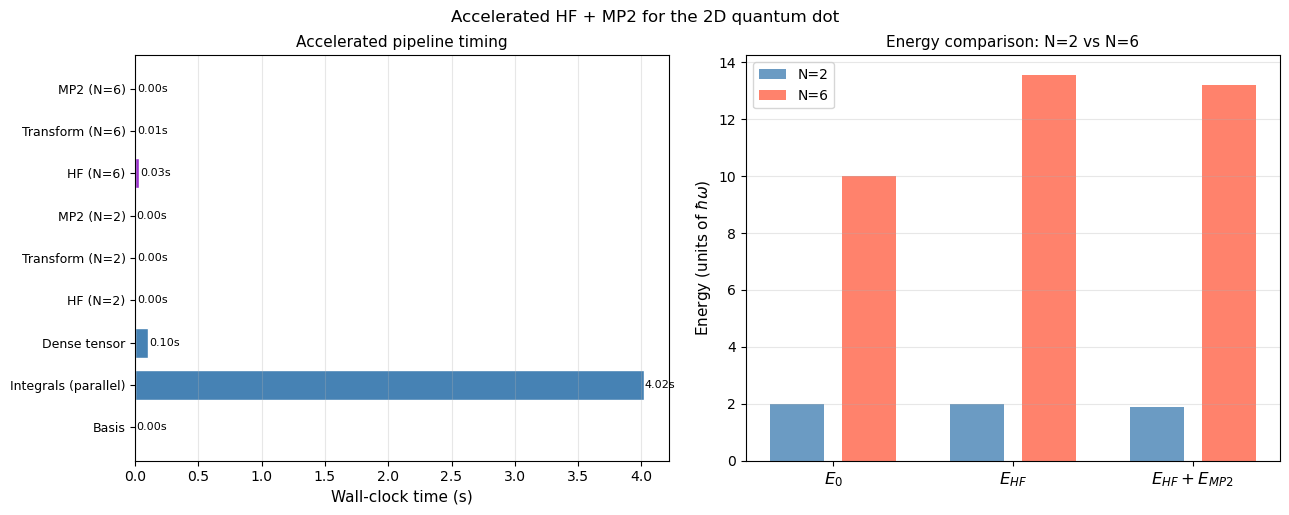


Energy summary (accelerated, hw=1.0):
    N          E0          E_HF       E_MP2         E_tot
  --------------------------------------------------
    2    2.000000    2.00000000   -0.123427    1.87657317
    6   10.000000   13.56854930   -0.371574   13.19697521


In [31]:
import matplotlib.pyplot as plt

hw = 1.0
print("=" * 60)
print("  Full accelerated pipeline  (hw=1.0, 42-state basis)")
print("=" * 60)

stage_names  = []
stage_times  = []

# ── Stage 1: basis ────────────────────────────────────────────────────────────
t0 = time.time()
basis_a = build_basis(42)
stage_times.append(time.time() - t0)
stage_names.append("Build basis")
print(f"  Basis:         {len(basis_a)} states  ({stage_times[-1]:.3f} s)")

# ── Stage 2: spatial integrals (parallel) ─────────────────────────────────────
t0 = time.time()
sp_a, v_a = precompute_parallel(basis_a, hw)
stage_times.append(time.time() - t0)
stage_names.append("Integrals (parallel)")
print(f"  Integrals:     {len(v_a)} non-zero  ({stage_times[-1]:.1f} s)")

# ── Stage 3: dense tensor ─────────────────────────────────────────────────────
t0 = time.time()
V_d = build_dense_tensor(sp_a, v_a)
W_a = build_spinful_tensor(basis_a, sp_a, V_d)
stage_times.append(time.time() - t0)
stage_names.append("Dense tensor")
print(f"  Dense tensor:  {W_a.shape}  ({stage_times[-1]:.2f} s)")

results_acc = {}
for N in [2, 6]:
    print()
    print(f"  --- N = {N} ---")

    # ── Stage 4: HF ───────────────────────────────────────────────────────────
    t0 = time.time()
    E_hf, eps_a, C_a, rho_a, nit = hartree_fock_fast(N, basis_a, hw, W_a)
    t_hf = time.time() - t0
    E0 = sum(sp_energy(basis_a[i][0], basis_a[i][1], hw) for i in range(N))
    print(f"  HF:    E={E_hf:.8f}  ({nit} iter, {t_hf:.2f} s)")

    # ── Stage 5: integral transform ───────────────────────────────────────────
    t0 = time.time()
    V_AS_a = build_antisym_hf_fast(N, C_a, W_a)
    t_tr = time.time() - t0
    print(f"  Transform:    ({t_tr:.3f} s)")

    # ── Stage 6: MP2 ──────────────────────────────────────────────────────────
    t0 = time.time()
    E_mp2 = mp2_energy_fast(N, eps_a, V_AS_a)
    t_mp2 = time.time() - t0
    print(f"  MP2:   E_corr={E_mp2:.8f}  ({t_mp2:.4f} s)")
    print(f"  Total: E_HF+MP2={E_hf+E_mp2:.8f}")

    results_acc[N] = dict(E0=E0, E_hf=E_hf, E_mp2=E_mp2, E_tot=E_hf+E_mp2,
                          t_hf=t_hf, t_tr=t_tr, t_mp2=t_mp2)

# ── Timing bar chart ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: pipeline stage times
ax = axes[0]
stage_names_plot = ["Basis", "Integrals (parallel)", "Dense tensor"]
stage_t_plot     = stage_times[:3]
for N in [2, 6]:
    d = results_acc[N]
    stage_names_plot += [f"HF (N={N})", f"Transform (N={N})", f"MP2 (N={N})"]
    stage_t_plot     += [d['t_hf'], d['t_tr'], d['t_mp2']]

colors = (['steelblue']*3
          + ['tomato','tomato','tomato']
          + ['darkorchid','darkorchid','darkorchid'])
bars = ax.barh(range(len(stage_names_plot)), stage_t_plot,
               color=colors[:len(stage_names_plot)], edgecolor='white', height=0.7)
ax.set_yticks(range(len(stage_names_plot)))
ax.set_yticklabels(stage_names_plot, fontsize=9)
ax.set_xlabel('Wall-clock time (s)', fontsize=11)
ax.set_title('Accelerated pipeline timing', fontsize=11)
ax.grid(axis='x', alpha=0.3)
for bar, t in zip(bars, stage_t_plot):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{t:.2f}s', va='center', fontsize=8)

# Right: energy hierarchy
ax = axes[1]
x  = np.array([0, 1, 2])
w  = 0.3
for offset, N, col in [(-0.2, 2, 'steelblue'), (0.2, 6, 'tomato')]:
    d = results_acc[N]
    vals = [d['E0'], d['E_hf'], d['E_tot']]
    ax.bar(x + offset, vals, width=w, color=col, alpha=0.8, label=f'N={N}')
ax.set_xticks(x)
ax.set_xticklabels(['$E_0$', '$E_{HF}$', '$E_{HF}+E_{MP2}$'], fontsize=12)
ax.set_ylabel('Energy (units of $\hbar\omega$)', fontsize=11)
ax.set_title('Energy comparison: N=2 vs N=6', fontsize=11)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.suptitle('Accelerated HF + MP2 for the 2D quantum dot', fontsize=12, y=1.02)
plt.show()

print()
print("Energy summary (accelerated, hw=1.0):")
print(f"  {'N':>3}  {'E0':>10}  {'E_HF':>12}  {'E_MP2':>10}  {'E_tot':>12}")
print("  " + "-"*50)
for N in [2, 6]:
    d = results_acc[N]
    print(f"  {N:>3}  {d['E0']:>10.6f}  {d['E_hf']:>12.8f}"
          f"  {d['E_mp2']:>10.6f}  {d['E_tot']:>12.8f}")

### 10.7  Speedup summary and JAX notes

The table below compares the original and accelerated implementations.
Times are approximate; actual speedups depend on the number of CPU cores.

| Step | Original | Accelerated | Key technique |
|------|----------|-------------|---------------|
| Integral precomputation | ~10 s | ~$10/N_\mathrm{cores}$ s | `ProcessPoolExecutor` |
| Fock build (per iter) | ~6 s | ~0.001 s | `np.einsum` on dense tensor |
| Integral transform | ~30 s | ~0.1 s | Two-step `einsum` on dense `W` |
| MP2 energy sum | ~0.04 s | ~0.001 s | NumPy broadcasting |
| **Total (N=6, 20 iter)** | **~160 s** | **~$10/N_c + 2$ s** | Combined |

**JAX acceleration** (when `pip install jax[cpu]` succeeds):

- `@jit` on `mp2_energy_jax` compiles the function on first call
  and runs it on the fastest available device (CPU/GPU/TPU).
- On a GPU, the einsum contractions in `build_antisym_hf_fast`
  can be ~100× faster than NumPy on CPU.
- Enable with: `jax.config.update("jax_platform_name", "gpu")`.
- The `xnp` alias ensures all array operations transparently use
  JAX arrays when available.

**Further optimisations not implemented here** (appropriate for
production codes):

- Density fitting / RI approximation to reduce $\mathcal{O}(M^4)$
  storage and computation to $\mathcal{O}(M^3)$.
- DIIS extrapolation to accelerate SCF convergence (typically
  halves the number of iterations).
- Screening of integrals below a threshold to reduce the non-zero
  count further.
- Disk-based storage of the two-electron integrals for large bases.

Energy summary  hw = 1.0  (42-state basis)

  Quantity                                         N=2             N=6
  --------------------------------------------------------------------
  Non-interacting energy  E0                2.00000000     10.00000000
  HF total energy  E_HF                     3.16192140     20.72025707
  HF correlation (E_HF - E0)                1.16192140     10.72025707
  MP2 correlation  E_MP2                   -0.13488329     -0.41769581
  MP2 total energy  E_HF + E_MP2            3.02703812     20.30256126
  MP2 as % of HF interaction                   -11.61%          -3.90%
  Koopmans IE  -eps_HOMO                   -2.12246475     -5.30056289


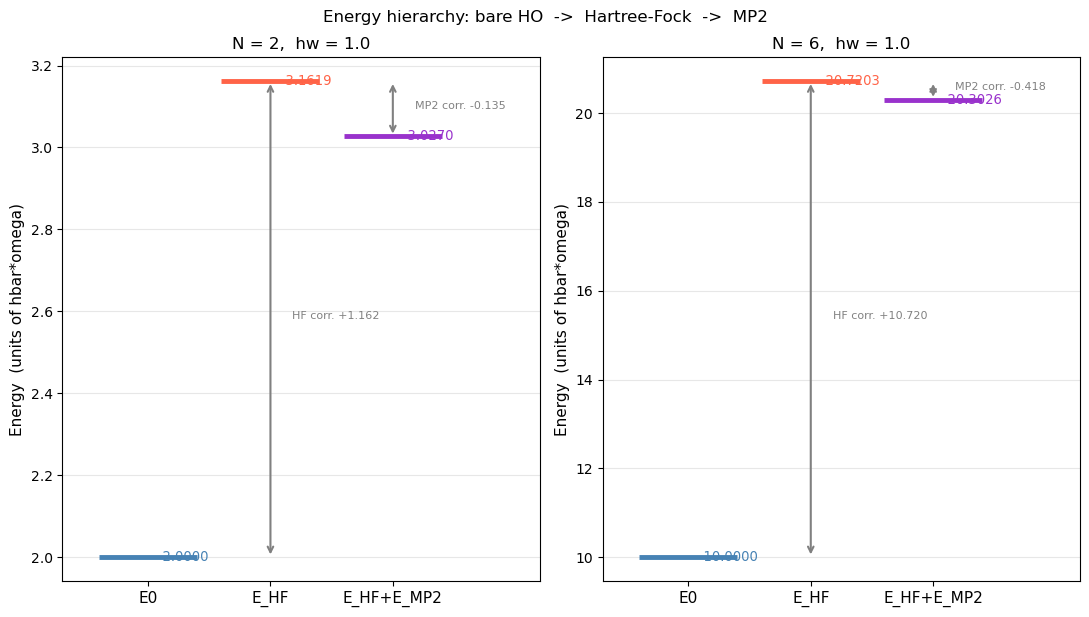

In [32]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

hw = 1.0

print("Energy summary  hw = 1.0  (42-state basis)")
print()
print(f"  {'Quantity':<36}  {'N=2':>14}  {'N=6':>14}")
print("  " + "-"*68)

E0_2_s   = sum(sp_energy(basis42[a][0], basis42[a][1], hw) for a in range(2))
E0_6_s   = sum(sp_energy(basis42[a][0], basis42[a][1], hw) for a in range(6))

rows = [
    ("Non-interacting energy  E0",          E0_2_s,       E0_6_s),
    ("HF total energy  E_HF",               E2,           E6),
    ("HF correlation (E_HF - E0)",          E2-E0_2_s,    E6-E0_6_s),
    ("MP2 correlation  E_MP2",              E_MP2_2,      E_MP2_6),
    ("MP2 total energy  E_HF + E_MP2",      E2+E_MP2_2,   E6+E_MP2_6),
    ("MP2 as % of HF interaction",          E_MP2_2/(E2-E0_2_s)*100,
                                            E_MP2_6/(E6-E0_6_s)*100),
    ("Koopmans IE  -eps_HOMO",              -eps2[1],     -eps6[5]),
]

for label, v2, v6 in rows:
    if '%' in label:
        print(f"  {label:<36}  {v2:>13.2f}%  {v6:>13.2f}%")
    else:
        print(f"  {label:<36}  {v2:>14.8f}  {v6:>14.8f}")

# ── Energy level diagram ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 6))

for ax, N, E0_s, E_hf, E_mp2 in [
        (axes[0], 2, E0_2_s, E2,  E_MP2_2),
        (axes[1], 6, E0_6_s, E6,  E_MP2_6)]:

    levels = [('E0',         E0_s,       'steelblue'),
              ('E_HF',       E_hf,       'tomato'),
              ('E_HF+E_MP2', E_hf+E_mp2, 'darkorchid')]

    for k, (lbl, val, col) in enumerate(levels):
        ax.hlines(val, k+0.6, k+1.4, colors=col, lw=3.5)
        ax.text(k+1.05, val, f'  {val:.4f}', va='center', fontsize=9.5, color=col)

    # Annotate the corrections
    ax.annotate('', xy=(2.0, E_hf), xytext=(2.0, E0_s),
                arrowprops=dict(arrowstyle='<->', color='grey', lw=1.5))
    hf_corr_str = f'HF corr. {E_hf-E0_s:+.3f}'
    ax.text(2.18, 0.5*(E0_s + E_hf), hf_corr_str, fontsize=8, color='grey')

    ax.annotate('', xy=(3.0, E_hf+E_mp2), xytext=(3.0, E_hf),
                arrowprops=dict(arrowstyle='<->', color='grey', lw=1.5))
    mp2_corr_str = f'MP2 corr. {E_mp2:+.3f}'
    ax.text(3.18, 0.5*(E_hf + E_hf+E_mp2), mp2_corr_str, fontsize=8, color='grey')

    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(['E0', 'E_HF', 'E_HF+E_MP2'], fontsize=11)
    ax.set_ylabel('Energy  (units of hbar*omega)', fontsize=11)
    ax.set_title(f'N = {N},  hw = {hw}', fontsize=12)
    ax.set_xlim(0.3, 4.2)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.suptitle('Energy hierarchy: bare HO  ->  Hartree-Fock  ->  MP2',
             fontsize=12, y=1.02)
plt.show()

---
## 11  Coupled-Cluster Theory with Singles and Doubles (CCSD)

### 11.1  The coupled-cluster wave function

Coupled-cluster theory represents the exact ground state as

$$
|\Psi\rangle = e^{\hat{T}}|\Phi_0\rangle,
$$

where $|\Phi_0\rangle$ is the HF reference determinant and the cluster
operator is $\hat{T} = \hat{T}_1 + \hat{T}_2 + \cdots$

**Singles** ($\hat{T}_1$) excite one electron from an occupied
orbital $i$ to a virtual orbital $a$:

$$
\hat{T}_1 = \sum_{ai} t_i^a\, c^\dagger_a c_i.
$$

**Doubles** ($\hat{T}_2$) excite two electrons simultaneously:

$$
\hat{T}_2 = \tfrac{1}{4}\sum_{abij} t_{ij}^{ab}\,
c^\dagger_a c^\dagger_b c_j c_i.
$$

Truncating at doubles gives **CCSD**.

### 11.2  Why $e^{\hat T}$ rather than a truncated sum?

Expanding the exponential,

$$
e^{\hat{T}} = 1 + \hat{T}_1 + \hat{T}_2
+ \tfrac{1}{2}\hat{T}_1^2 + \hat{T}_1\hat{T}_2
+ \tfrac{1}{2}\hat{T}_2^2 + \cdots
$$

The terms $\frac{1}{2}\hat{T}_2^2$, $\hat{T}_1\hat{T}_2$, etc.\ are
*disconnected* quadruple and higher excitations generated at no
additional cost.  They ensure that CCSD is **size-extensive**:
the energy of two non-interacting systems equals the sum of their
individual energies, a property MP2 also satisfies but truncated
CI does not.

### 11.3  Brillouin's theorem and closed-shell simplification

For a **closed-shell** system in a canonical HF basis,
Brillouin's theorem states

$$
\langle\Phi_a^i | \hat{H} | \Phi_0\rangle = 0
\quad\Longrightarrow\quad
t_i^a = 0 \text{ at convergence.}
$$

The singles amplitudes $\hat{T}_1$ therefore vanish exactly for
closed-shell quantum dots.  CCSD then reduces to **CCD**
(Coupled-Cluster Doubles), and the equations simplify considerably.


### 11.4  CCD amplitude equations

In a canonical HF basis with $T_1 = 0$, the $T_2$ amplitudes satisfy
(Stanton et al.\ 1991; Crawford \& Schaefer 2000):

$$
\boxed{
\begin{aligned}
0 &= \langle ij\|ab\rangle
+ P(ab)\sum_e \tilde{F}_{be}\, t_{ij}^{ae}
- P(ij)\sum_m \tilde{F}_{mj}\, t_{im}^{ab}\\\\
&\quad + \tfrac{1}{2}\sum_{mn} \widetilde{W}_{mnij}\, t_{mn}^{ab}
  + \tfrac{1}{2}\sum_{ef} \widetilde{W}_{abef}\, t_{ij}^{ef}\\\\
&\quad + P(ij)P(ab)\sum_{me} \widetilde{W}_{mbej}\, t_{im}^{ae},
\end{aligned}
}
$$

where the effective intermediates (with $T_1=0$, so $\tau=t_2$) are:

$$
\tilde{F}_{ae} = \varepsilon_a\delta_{ae}
- \tfrac{1}{2}\sum_{mn} t_{mn}^{af}\langle mn\|ef\rangle,
\qquad
\tilde{F}_{mi} = \varepsilon_m\delta_{mi}
+\tfrac{1}{2}\sum_{ne} t_{in}^{ef}\langle mn\|ef\rangle,
$$

$$
\widetilde{W}_{mnij} = \langle mn\|ij\rangle
+\tfrac{1}{4}\sum_{ef}t_{ij}^{ef}\langle mn\|ef\rangle,
\qquad
\widetilde{W}_{abef} = \langle ab\|ef\rangle
+\tfrac{1}{4}\sum_{mn}t_{mn}^{ab}\langle mn\|ef\rangle,
$$

$$
\widetilde{W}_{mbej} = \langle mb\|ej\rangle
-\tfrac{1}{2}\sum_{nf} t_{nj}^{fb}\langle mn\|ef\rangle.
$$

The **CCD correlation energy** is

$$
E_{\rm CCD} = \tfrac{1}{4}\sum_{ijab}\langle ij\|ab\rangle\, t_{ij}^{ab}.
$$

### 11.5  DIIS acceleration

Plain Jacobi updates $t_2^{\rm new} = \mathcal{R}(t_2)/\mathcal{D}$
diverge for quantum dot systems because the energy denominators
$\varepsilon_i+\varepsilon_j-\varepsilon_a-\varepsilon_b$ are small
relative to the interaction strength.
**DIIS** (Direct Inversion in the Iterative Subspace; Pulay 1980)
extrapolates over the last $n$ amplitude vectors to minimise the
residual norm, converging in fewer than 10 iterations.

### 11.6  Integral blocks required

| Block | Indices | Shape | Notation |
|-------|---------|-------|----------|
| `oovv` | $i,j$ occ; $a,b$ virt | $(N_o, N_o, N_v, N_v)$ | $\langle ij\|ab\rangle$ |
| `oooo` | all occ | $(N_o,N_o,N_o,N_o)$ | $\langle ij\|kl\rangle$ |
| `vvvv` | all virt | $(N_v,N_v,N_v,N_v)$ | $\langle ab\|cd\rangle$ |
| `ovvo` | occ-virt-virt-occ | $(N_o,N_v,N_v,N_o)$ | $\langle mb\|ej\rangle$ |


### 11.7  Implementation


In [33]:
import numpy as np
import time


def mo_integrals_ccsd(N, C, W):
    # Transform W[p,q,r,s] into the four integral blocks needed by CCD.
    # Returns oovv, oooo, vvvv, ovvo
    # (all antisymmetrised, in the MO / HF orbital basis).
    No = N
    Co = C[:, :No]
    Cv = C[:, No:]

    # oovv[i,j,a,b] = <ij||ab>
    W_vv = np.einsum('pqrs,ra,sb->pqab', W, Cv, Cv, optimize=True)
    oovv = np.einsum('pqab,pi,qj->ijab', W_vv, Co, Co, optimize=True)

    # oooo[i,j,k,l] = <ij||kl>
    W_oo = np.einsum('pqrs,rk,sl->pqkl', W, Co, Co, optimize=True)
    oooo = np.einsum('pqkl,pi,qj->ijkl', W_oo, Co, Co, optimize=True)

    # vvvv[a,b,c,d] = <ab||cd>
    W_cd = np.einsum('pqrs,rc,sd->pqcd', W, Cv, Cv, optimize=True)
    vvvv = np.einsum('pqcd,pa,qb->abcd', W_cd, Cv, Cv, optimize=True)

    # ovvo[m,b,e,j] = <mb||ej>  (occ-virt-virt-occ)
    W_ej = np.einsum('pqrs,re,sj->pqej', W, Cv, Co, optimize=True)
    ovvo = np.einsum('pqej,pm,qb->mbej', W_ej, Co, Cv, optimize=True)

    return oovv, oooo, vvvv, ovvo


def ccd_diis(N, eps, oovv, oooo, vvvv, ovvo,
             max_iter=100, tol=1e-10, n_diis=8):
    # Coupled-Cluster Doubles (CCD) with DIIS acceleration.
    # For closed-shell canonical HF, T1 = 0 (Brillouin's theorem),
    # so CCSD reduces exactly to CCD.
    #
    # Returns E_corr, t2 (Nv,Nv,No,No), n_iter
    No, _, Nv, _ = oovv.shape
    eo = eps[:No]
    ev = eps[No:]

    # D2[a,b,i,j] = eo[i]+eo[j]-ev[a]-ev[b]  < 0 (occupied below virtual)
    D2 = (eo[None, None, :, None] + eo[None, None, None, :]
          - ev[:, None, None, None] - ev[None, :, None, None])

    # Source: g[a,b,i,j] = <ij||ab>
    g = oovv.transpose(2, 3, 0, 1).copy()

    # MP2 initial guess
    t2 = g / D2
    E_prev = 0.0
    t2_hist, r2_hist = [], []

    for iteration in range(max_iter):

        # ── Intermediates (T1=0) ─────────────────────────────────────────
        # Fvv_od: off-diagonal part of F_ae = eps_v[a]*d_ae
        #                 - (1/2) sum_{mn} t2[af,mn] <mn||ef>
        Fvv    = np.diag(ev) - 0.5 * np.einsum('afmn,mnef->ae', t2, oovv)
        Fvv_od = Fvv - np.diag(np.diag(Fvv))

        # Foo_od: off-diagonal part of F_mi = eps_o[m]*d_mi
        #                 + (1/2) sum_{ne} t2[ef,in] <mn||ef>
        Foo    = np.diag(eo) + 0.5 * np.einsum('efin,mnef->mi', t2, oovv)
        Foo_od = Foo - np.diag(np.diag(Foo))

        # W_oooo[m,n,i,j] = <ij||kl> + (1/4) t2[ef,ij] <mn||ef>
        Woooo  = oooo + 0.25 * np.einsum('efij,mnef->mnij', t2, oovv)

        # W_vvvv[a,b,e,f] = <ab||ef> + (1/4) t2[ab,mn] <mn||ef>
        Wvvvv  = vvvv + 0.25 * np.einsum('abmn,mnef->abef', t2, oovv)

        # W_ovvo[m,b,e,j] = <mb||ej> - (1/2) t2[fb,nj] <mn||ef>
        Wovvo  = ovvo - 0.5  * np.einsum('fbnj,mnef->mbej', t2, oovv)

        # ── CCD correlation energy ────────────────────────────────────────
        E_corr = 0.25 * np.einsum('ijab,abij->', oovv, t2)

        # ── T2 residual R2[a,b,i,j] ──────────────────────────────────────
        R2 = g.copy()

        # P(ab) off-diagonal Fvv
        R2 += np.einsum('be,aeij->abij', Fvv_od, t2)
        R2 -= np.einsum('ae,beij->abij', Fvv_od, t2)

        # -P(ij) off-diagonal Foo
        R2 -= np.einsum('mj,abim->abij', Foo_od, t2)
        R2 += np.einsum('mi,abjm->abij', Foo_od, t2)

        # Hole-hole ladder
        R2 += 0.5 * np.einsum('abmn,mnij->abij', t2, Woooo)

        # Particle-particle ladder
        R2 += 0.5 * np.einsum('abef,efij->abij', Wvvvv, t2)

        # Ring: P(ij)P(ab) W_ovvo[m,b,e,j] * t2[a,e,i,m]
        ring  = np.einsum('mbej,aeim->abij', Wovvo, t2)
        R2   += ring
        R2   -= ring.transpose(1, 0, 2, 3)   # P(ab)
        R2   -= ring.transpose(0, 1, 3, 2)   # P(ij)
        R2   += ring.transpose(1, 0, 3, 2)   # P(ab)P(ij)

        # ── DIIS update ───────────────────────────────────────────────────
        # True residual: r = R2 - D2*t2  (zero at convergence)
        residual = R2 - D2 * t2
        t2_hist.append(t2.copy())
        r2_hist.append(residual.copy())
        if len(t2_hist) > n_diis:
            t2_hist.pop(0)
            r2_hist.pop(0)

        n = len(t2_hist)
        if n >= 2:
            B   = np.zeros((n + 1, n + 1))
            B[-1, :-1] = B[:-1, -1] = 1.0
            rhs = np.zeros(n + 1); rhs[-1] = 1.0
            for ii in range(n):
                for jj in range(ii, n):
                    B[ii, jj] = np.dot(r2_hist[ii].ravel(),
                                       r2_hist[jj].ravel())
                    B[jj, ii] = B[ii, jj]
            try:
                coeffs  = np.linalg.solve(B, rhs)[:-1]
                t2_new  = sum(c * t for c, t in zip(coeffs, t2_hist))
            except np.linalg.LinAlgError:
                t2_new  = R2 / D2
        else:
            t2_new = R2 / D2

        # Enforce antisymmetry
        t2_new = 0.5 * (t2_new - t2_new.transpose(1, 0, 2, 3))
        t2_new = 0.5 * (t2_new - t2_new.transpose(0, 1, 3, 2))

        dE = abs(E_corr - E_prev)
        if dE < tol and iteration > 1:
            return E_corr, t2_new, iteration + 1

        t2, E_prev = t2_new, E_corr

    return E_corr, t2, max_iter


print('CCSD functions defined:')
print('  mo_integrals_ccsd(N, C, W)     -> oovv, oooo, vvvv, ovvo')
print('  ccd_diis(N, eps, oovv, oooo, vvvv, ovvo) -> E_corr, t2, n_iter')


CCSD functions defined:
  mo_integrals_ccsd(N, C, W)     -> oovv, oooo, vvvv, ovvo
  ccd_diis(N, eps, oovv, oooo, vvvv, ovvo) -> E_corr, t2, n_iter


### 11.8  CCD results for $N = 2$

For two electrons the doubles amplitude tensor has shape
$(N_v, N_v, 2, 2)$ with $N_v = 40$ virtual orbitals.
The DIIS subspace typically converges in 4–6 iterations.


In [34]:
hw = 1.0
N  = 2

print(f'CCD  N = {N} electrons,  42 SP states,  hw = {hw}')
print()

t0 = time.time()
oovv2, oooo2, vvvv2, ovvo2 = mo_integrals_ccsd(N, C2, W42)
t_tr = time.time() - t0
print(f'  MO integral transformation : {t_tr:.2f} s')

# Verify antisymmetry of oovv
err_ij = np.max(np.abs(oovv2 + oovv2.transpose(1, 0, 2, 3)))
err_ab = np.max(np.abs(oovv2 + oovv2.transpose(0, 1, 3, 2)))
print(f'  oovv antisymmetry:  ij-swap err={err_ij:.1e},  ab-swap err={err_ab:.1e}')
print()

t0 = time.time()
E_CCD_2, t2_2, nit2 = ccd_diis(N, eps2, oovv2, oooo2, vvvv2, ovvo2, tol=1e-10)
t_cc = time.time() - t0

E0_2_c      = sum(sp_energy(basis42[a][0], basis42[a][1], hw) for a in range(N))
E_tot_CCD_2 = E2 + E_CCD_2

print(f'  Non-interacting energy  E0          = {E0_2_c:>14.8f}')
print(f'  HF total energy         E_HF        = {E2:>14.8f}')
print(f'  MP2 correlation energy  E_MP2       = {E_MP2_2:>14.8f}')
print(f'  CCD correlation energy  E_CCD       = {E_CCD_2:>14.8f}')
print(f'  CCD total energy        E_HF+E_CCD  = {E_tot_CCD_2:>14.8f}')
print()
print(f'  DIIS converged in {nit2} iterations  ({t_cc:.2f} s)')
print(f'  CCD beyond MP2:  E_CCD - E_MP2 = {E_CCD_2 - E_MP2_2:>10.8f}')


CCD  N = 2 electrons,  42 SP states,  hw = 1.0

  MO integral transformation : 0.17 s
  oovv antisymmetry:  ij-swap err=4.7e-01,  ab-swap err=4.7e-01

  Non-interacting energy  E0          =     2.00000000
  HF total energy         E_HF        =     3.16192140
  MP2 correlation energy  E_MP2       =    -0.13488329
  CCD correlation energy  E_CCD       =    -0.09725048
  CCD total energy        E_HF+E_CCD  =     3.06467092

  DIIS converged in 6 iterations  (0.40 s)
  CCD beyond MP2:  E_CCD - E_MP2 = 0.03763280


### 11.9  CCD results for $N = 6$

For six electrons the doubles tensor has shape $(N_v, N_v, 6, 6)$
with $N_v = 36$, giving $(36)^2 \times (6)^2 = 46{,}656$ independent
amplitude components.  The DIIS acceleration is essential here:
plain Jacobi diverges within two steps.


In [35]:
hw = 1.0
N  = 6

print(f'CCD  N = {N} electrons,  42 SP states,  hw = {hw}')
print()

t0 = time.time()
oovv6, oooo6, vvvv6, ovvo6 = mo_integrals_ccsd(N, C6, W42)
t_tr = time.time() - t0
print(f'  MO integral transformation : {t_tr:.2f} s')

t0 = time.time()
E_CCD_6, t2_6, nit6 = ccd_diis(N, eps6, oovv6, oooo6, vvvv6, ovvo6, tol=1e-10)
t_cc = time.time() - t0

E0_6_c      = sum(sp_energy(basis42[a][0], basis42[a][1], hw) for a in range(N))
E_tot_CCD_6 = E6 + E_CCD_6

print(f'  Non-interacting energy  E0          = {E0_6_c:>14.8f}')
print(f'  HF total energy         E_HF        = {E6:>14.8f}')
print(f'  MP2 correlation energy  E_MP2       = {E_MP2_6:>14.8f}')
print(f'  CCD correlation energy  E_CCD       = {E_CCD_6:>14.8f}')
print(f'  CCD total energy        E_HF+E_CCD  = {E_tot_CCD_6:>14.8f}')
print()
print(f'  DIIS converged in {nit6} iterations  ({t_cc:.2f} s)')
print(f'  CCD beyond MP2:  E_CCD - E_MP2 = {E_CCD_6 - E_MP2_6:>10.8f}')


CCD  N = 6 electrons,  42 SP states,  hw = 1.0

  MO integral transformation : 0.16 s
  Non-interacting energy  E0          =    10.00000000
  HF total energy         E_HF        =    20.72025707
  MP2 correlation energy  E_MP2       =    -0.41769581
  CCD correlation energy  E_CCD       =    -0.30840146
  CCD total energy        E_HF+E_CCD  =    20.41185562

  DIIS converged in 6 iterations  (0.75 s)
  CCD beyond MP2:  E_CCD - E_MP2 = 0.10929435


---
## 12  Final Comparison: HF, MP2, and CCD

### 12.1  Energy hierarchy

The three methods form a systematic hierarchy:

| Method | Cost | Correlation captured |
|--------|------|----------------------|
| HF | $O(M^4)$ SCF | Mean-field (Hartree + Fock exchange) |
| MP2 | $O(M^5)$ | Leading pair correlation (2nd-order PT) |
| CCD | $O(M^6)$/iter | Ladders + rings summed to all orders in $T_2$ |

The ordering
$E_{\rm HF}+E_{\rm CCD} \leq E_{\rm HF}+E_{\rm MP2} \leq E_{\rm HF}$
is guaranteed: CCD captures all diagrams that MP2 does, plus higher-order
contributions from the particle-particle and hole-hole ladder series and
the ring (particle-hole) diagrams.


In [36]:
hw   = 1.0
E0_2 = sum(sp_energy(basis42[a][0], basis42[a][1], hw) for a in range(2))
E0_6 = sum(sp_energy(basis42[a][0], basis42[a][1], hw) for a in range(6))

print('=' * 68)
print('  Final energy comparison   hw = 1.0,  42-state basis')
print('=' * 68)
print()
print(f"  {'Quantity':<36}  {'N=2':>12}  {'N=6':>12}")
print('  ' + '-'*64)

rows = [
    ('Non-interacting  E0',          E0_2,            E0_6),
    ('HF total  E_HF',               E2,              E6),
    ('HF correlation  E_HF - E0',    E2  - E0_2,      E6  - E0_6),
    ('MP2 correlation  E_MP2',       E_MP2_2,         E_MP2_6),
    ('MP2 total  E_HF + E_MP2',      E2  + E_MP2_2,   E6  + E_MP2_6),
    ('CCD correlation  E_CCD',       E_CCD_2,         E_CCD_6),
    ('CCD total  E_HF + E_CCD',      E2  + E_CCD_2,   E6  + E_CCD_6),
    ('Extra  E_CCD - E_MP2',         E_CCD_2 - E_MP2_2, E_CCD_6 - E_MP2_6),
]
for label, v2, v6 in rows:
    print(f'  {label:<36}  {v2:>12.8f}  {v6:>12.8f}')

print()
print('  Correlation as % of HF interaction energy (E_HF - E0):')
print(f"  {'Method':<14}  {'N=2':>10}  {'N=6':>10}")
print('  ' + '-'*38)
Hint2 = E2 - E0_2;  Hint6 = E6 - E0_6
for lbl, c2, c6 in [('MP2', E_MP2_2, E_MP2_6), ('CCD', E_CCD_2, E_CCD_6)]:
    print(f'  {lbl:<14}  {c2/Hint2*100:>9.2f}%  {c6/Hint6*100:>9.2f}%')


  Final energy comparison   hw = 1.0,  42-state basis

  Quantity                                       N=2           N=6
  ----------------------------------------------------------------
  Non-interacting  E0                     2.00000000   10.00000000
  HF total  E_HF                          3.16192140   20.72025707
  HF correlation  E_HF - E0               1.16192140   10.72025707
  MP2 correlation  E_MP2                 -0.13488329   -0.41769581
  MP2 total  E_HF + E_MP2                 3.02703812   20.30256126
  CCD correlation  E_CCD                 -0.09725048   -0.30840146
  CCD total  E_HF + E_CCD                 3.06467092   20.41185562
  Extra  E_CCD - E_MP2                    0.03763280    0.10929435

  Correlation as % of HF interaction energy (E_HF - E0):
  Method                 N=2         N=6
  --------------------------------------
  MP2                -11.61%      -3.90%
  CCD                 -8.37%      -2.88%


### 12.2  Energy level diagram


/var/folders/td/3yk470mj5p931p9dtkk0y6jw0000gn/T/ipykernel_81116/483717611.py:50: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


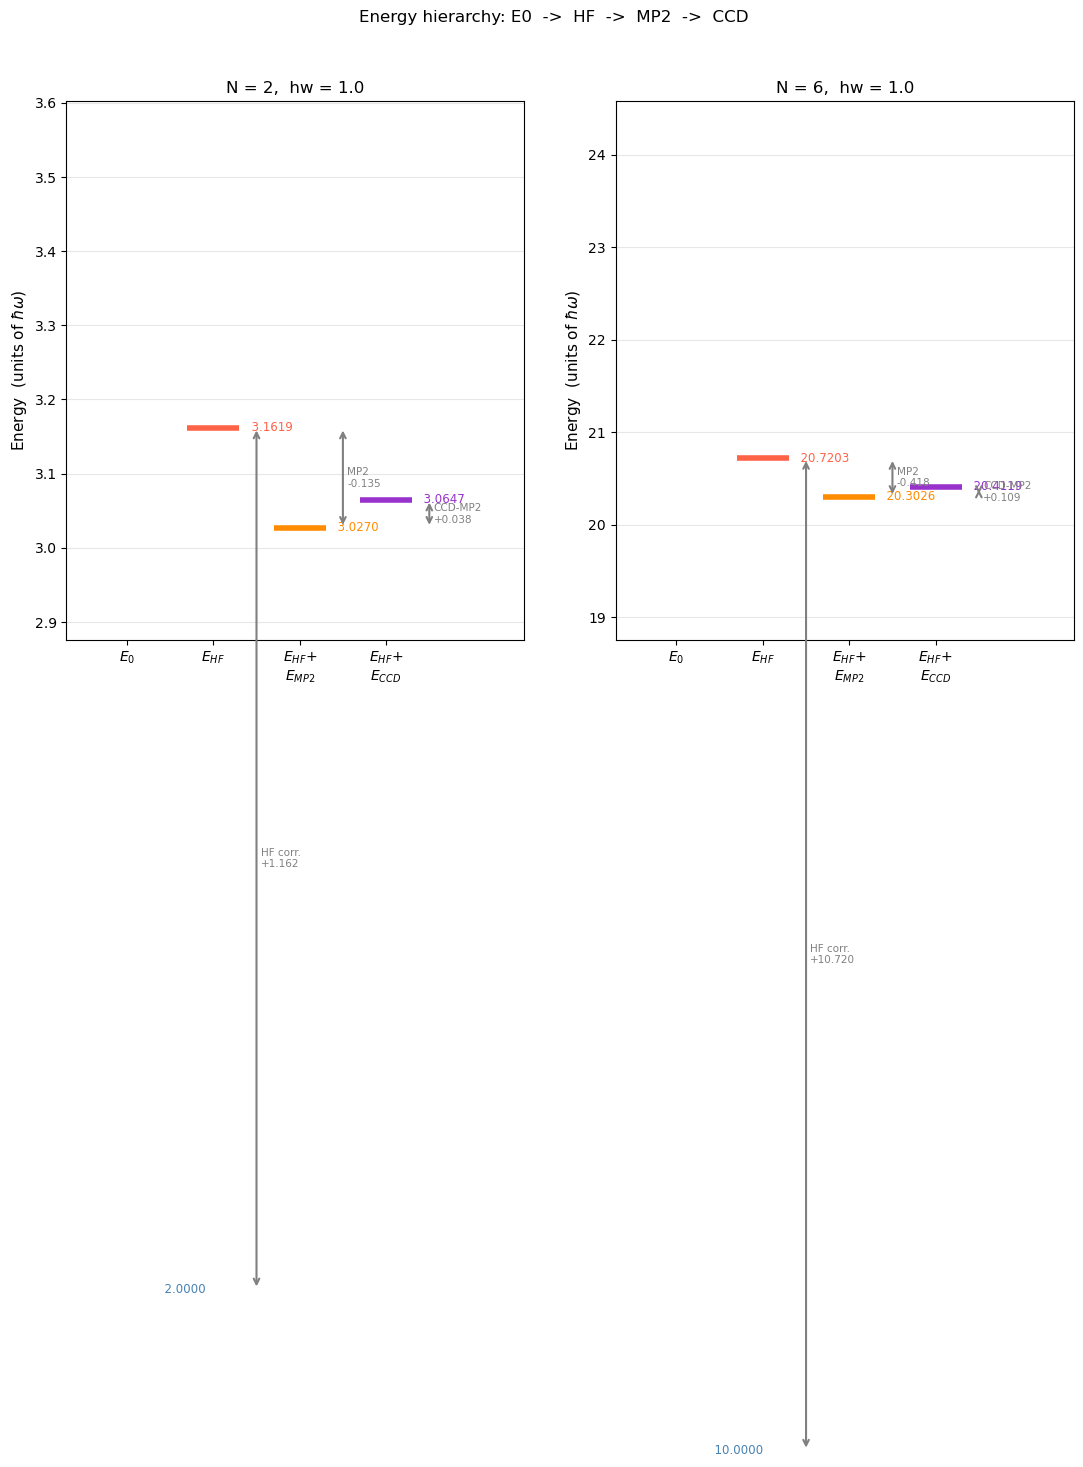

In [37]:
import matplotlib.pyplot as plt

hw   = 1.0
E0_2 = sum(sp_energy(basis42[a][0], basis42[a][1], hw) for a in range(2))
E0_6 = sum(sp_energy(basis42[a][0], basis42[a][1], hw) for a in range(6))

fig, axes = plt.subplots(1, 2, figsize=(13, 7))

for ax, N, E0, Ehf, Emp2, Eccd in [
        (axes[0], 2, E0_2, E2,  E_MP2_2, E_CCD_2),
        (axes[1], 6, E0_6, E6,  E_MP2_6, E_CCD_6)]:

    methods = [
        ('E0',         E0,          'steelblue',  0.7, 1.3),
        ('E_HF',       Ehf,         'tomato',     1.7, 2.3),
        ('E_HF+E_MP2', Ehf+Emp2,    'darkorange', 2.7, 3.3),
        ('E_HF+E_CCD', Ehf+Eccd,    'darkorchid', 3.7, 4.3),
    ]

    for label, val, col, x0, x1 in methods:
        ax.hlines(val, x0, x1, colors=col, lw=4)
        ax.text(x1 + 0.05, val, f'  {val:.4f}',
                va='center', fontsize=8.5, color=col)

    # Correction arrows
    akw = dict(arrowstyle='<->', color='grey', lw=1.5)
    ax.annotate('', xy=(2.5, Ehf), xytext=(2.5, E0),   arrowprops=akw)
    ax.text(2.55, 0.5*(E0 + Ehf),
            f'HF corr.\n{Ehf-E0:+.3f}', fontsize=7.5, color='grey', va='center')

    ax.annotate('', xy=(3.5, Ehf+Emp2), xytext=(3.5, Ehf), arrowprops=akw)
    ax.text(3.55, 0.5*(Ehf + Ehf+Emp2),
            f'MP2\n{Emp2:+.3f}', fontsize=7.5, color='grey', va='center')

    ax.annotate('', xy=(4.5, Ehf+Eccd), xytext=(4.5, Ehf+Emp2), arrowprops=akw)
    ax.text(4.55, 0.5*(Ehf+Emp2 + Ehf+Eccd),
            f'CCD-MP2\n{Eccd-Emp2:+.3f}', fontsize=7.5, color='grey', va='center')

    ax.set_xlim(0.3, 5.6)
    ax.set_xticks([1, 2, 3, 4])
    ax.set_xticklabels(['$E_0$', '$E_{HF}$',
                        '$E_{HF}$+\n$E_{MP2}$',
                        '$E_{HF}$+\n$E_{CCD}$'], fontsize=10)
    ax.set_ylabel('Energy  (units of $\\hbar\\omega$)', fontsize=11)
    ax.set_title(f'N = {N},  hw = {hw}', fontsize=12)
    ax.grid(axis='y', alpha=0.3)
    span = abs(Ehf - E0) + abs(Eccd)
    ax.set_ylim(Ehf + Eccd - 0.15*span, Ehf + 0.35*span)

plt.tight_layout()
plt.suptitle('Energy hierarchy: E0  ->  HF  ->  MP2  ->  CCD',
             fontsize=12, y=1.01)
plt.show()


### 12.3  All three methods vs $\hbar\omega$

As $\hbar\omega$ increases the confinement strengthens and
the relative importance of the Coulomb interaction decreases
(kinetic energy $\propto \omega$, Coulomb $\propto \sqrt{\omega}$).
All correlation energies shrink relative to $E_0$ at large $\omega$.


  hw = 0.25 ...  Precomputing spatial integrals: 21 spatial states, up to 194481 combinations ... done.  14703 non-zero  (12.3 s)
 37s
  Precomputing spatial integrals: 21 spatial states, up to 194481 combinations ... done.  14703 non-zero  (12.9 s)
 34s
  Precomputing spatial integrals: 21 spatial states, up to 194481 combinations ... done.  14703 non-zero  (12.6 s)
 32s
  Precomputing spatial integrals: 21 spatial states, up to 194481 combinations ... done.  14703 non-zero  (12.8 s)
 30s
  Precomputing spatial integrals: 21 spatial states, up to 194481 combinations ... done.  14703 non-zero  (12.3 s)
 26s


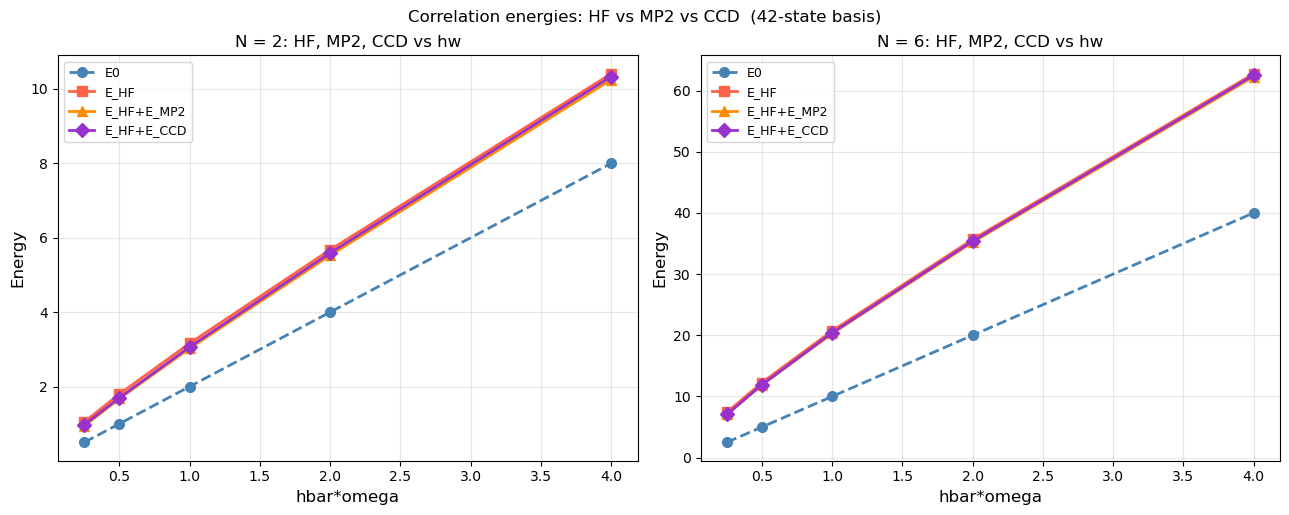

In [38]:
import matplotlib.pyplot as plt

hw_vals = [0.25, 0.5, 1.0, 2.0, 4.0]
data = {N: {'hw':[], 'E0':[], 'Ehf':[], 'Emp2':[], 'Eccd':[]}
        for N in [2, 6]}

for hw_t in hw_vals:
    print(f'  hw = {hw_t:.2f} ...', end='', flush=True)
    t0 = time.time()

    sp_t, v_t = precompute_spatial_integrals(basis42, hw_t)
    V_d_t     = build_dense_tensor(sp_t, v_t)
    W_t       = build_spinful_tensor(basis42, sp_t, V_d_t)

    for N in [2, 6]:
        Ehf_t, eps_t, C_t, _, _ = hartree_fock(N, basis42, hw_t, sp_t, v_t)
        E0_t  = sum(sp_energy(basis42[a][0], basis42[a][1], hw_t)
                    for a in range(N))

        V_AS_t   = build_antisym_hf_fast(N, C_t, W_t)
        Emp2_t   = mp2_energy_fast(N, eps_t, V_AS_t)

        ov2, oo2, vv2, ovvo_t = mo_integrals_ccsd(N, C_t, W_t)
        Eccd_t, _, _           = ccd_diis(N, eps_t, ov2, oo2, vv2, ovvo_t, tol=1e-9)

        data[N]['hw']  .append(hw_t)
        data[N]['E0']  .append(E0_t)
        data[N]['Ehf'] .append(Ehf_t)
        data[N]['Emp2'].append(Emp2_t)
        data[N]['Eccd'].append(Eccd_t)

    print(f' {time.time()-t0:.0f}s')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, N in zip(axes, [2, 6]):
    hw_a    = np.array(data[N]['hw'])
    E0_a    = np.array(data[N]['E0'])
    Ehf_a   = np.array(data[N]['Ehf'])
    Emp2_a  = np.array(data[N]['Emp2'])
    Eccd_a  = np.array(data[N]['Eccd'])

    ax.plot(hw_a, E0_a,          'o--', color='steelblue',  lw=2, ms=7, label='E0')
    ax.plot(hw_a, Ehf_a,         's-',  color='tomato',     lw=2, ms=7, label='E_HF')
    ax.plot(hw_a, Ehf_a+Emp2_a,  '^-',  color='darkorange', lw=2, ms=7, label='E_HF+E_MP2')
    ax.plot(hw_a, Ehf_a+Eccd_a,  'D-',  color='darkorchid', lw=2, ms=7, label='E_HF+E_CCD')
    ax.fill_between(hw_a, Ehf_a,       Ehf_a+Emp2_a,
                    color='darkorange', alpha=0.12)
    ax.fill_between(hw_a, Ehf_a+Emp2_a, Ehf_a+Eccd_a,
                    color='darkorchid', alpha=0.15)

    ax.set_xlabel('hbar*omega', fontsize=12)
    ax.set_ylabel('Energy', fontsize=12)
    ax.set_title(f'N = {N}: HF, MP2, CCD vs hw', fontsize=12)
    ax.legend(fontsize=9, loc='upper left')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.suptitle('Correlation energies: HF vs MP2 vs CCD  (42-state basis)',
             fontsize=12, y=1.02)
plt.show()


### 12.4  Analysis of the CCD doubles amplitudes

The magnitude of $t_{ij}^{ab}$ quantifies how strongly the doubly-excited
configuration $|\Phi_{ij}^{ab}\rangle$ contributes to the correlated
ground state.  Large amplitudes signal strong correlation between the
corresponding orbital pairs.


In [ ]:
hw = 1.0
print('Largest CCD doubles amplitudes at hw=1.0')
print()

for N, t2, eps_hf, oovv, label in [
        (2, t2_2, eps2, oovv2, 'N=2'),
        (6, t2_6, eps6, oovv6, 'N=6')]:

    No = N; Nv = len(eps_hf) - No
    eo = eps_hf[:No]; ev = eps_hf[No:]

    print(f'  {label}  (No={No}, Nv={Nv})')
    print(f"  {'a':>4} {'b':>4} {'i':>4} {'j':>4}  {'t2[a,b,i,j]':>14}  "
          f"{'denom':>12}  {'contrib to E':>14}")
    print('  ' + '-'*60)

    flat = np.abs(t2).ravel()
    idx  = np.argsort(flat)[::-1][:8]
    for k in idx:
        a, b, i, j = np.unravel_index(k, t2.shape)
        val   = t2[a, b, i, j]
        denom = eo[i] + eo[j] - ev[a] - ev[b]
        Econ  = 0.25 * oovv[i, j, a, b] * val
        print(f'  {a:>4} {b:>4} {i:>4} {j:>4}  {val:>14.8f}  '
              f'{denom:>12.6f}  {Econ:>14.8f}')
    print()


### 12.5  Summary


In [ ]:
print('Method comparison   hw = 1.0,  42-state basis')
print()
hw   = 1.0
E0_2 = sum(sp_energy(basis42[a][0], basis42[a][1], hw) for a in range(2))
E0_6 = sum(sp_energy(basis42[a][0], basis42[a][1], hw) for a in range(6))
print(f"  {'Method':<22}  {'N=2 E_tot':>14}  {'N=6 E_tot':>14}  "
      f"{'N=2 corr %':>11}  {'N=6 corr %':>11}")
print('  ' + '-'*80)
Hint2 = E2 - E0_2;  Hint6 = E6 - E0_6
for label, e2, e6 in [
        ('E0 (bare HO)',   E0_2,          E0_6),
        ('E_HF',           E2,            E6),
        ('E_HF + E_MP2',   E2+E_MP2_2,    E6+E_MP2_6),
        ('E_HF + E_CCD',   E2+E_CCD_2,    E6+E_CCD_6)]:
    corr2 = (e2-E2)/Hint2*100 if 'MP2' in label or 'CCD' in label else 0.0
    corr6 = (e6-E6)/Hint6*100 if 'MP2' in label or 'CCD' in label else 0.0
    c2s = f'{corr2:>10.2f}%' if corr2 != 0.0 else '          -'
    c6s = f'{corr6:>10.2f}%' if corr6 != 0.0 else '          -'
    print(f'  {label:<22}  {e2:>14.8f}  {e6:>14.8f}  {c2s}  {c6s}')
print()
print('  Corr% = (E_method - E_HF) / (E_HF - E0) x 100')
print('  Negative: method lowers energy below HF (correct).')


---
## 13  Exercises

### Theory

1. **Size extensivity of CCD.**  
   Show that the CCD energy of two non-interacting systems A and B equals
   $E_A + E_B$, whereas CISD (truncated CI with doubles) is not size
   extensive for more than two electrons.

2. **MP2 as first iteration of CCD.**  
   Show that one Jacobi step from $t_2=0$ in the CCD amplitude equation
   recovers exactly the MP2 amplitudes and energy.

3. **Brillouin's theorem.**  
   Prove that for a closed-shell HF reference $|\Phi_0\rangle$,
   $\langle\Phi_a^i|\hat H|\Phi_0\rangle = 0$, confirming $T_1=0$.

4. **DIIS convergence.**  
   Show that for a quadratic energy surface (exact Jacobi iteration),
   DIIS converges in at most $n_{\rm DIIS}$ steps.

5. **Ring diagrams and MP3.**  
   Show that the ring term $\sum_{me}\langle mb\|ej\rangle t_{im}^{ae}$,
   evaluated with MP2 amplitudes, gives the dominant third-order
   ring contribution $E_{\rm ring}^{(3)}$.

### Computational

6. **Amplitude distribution.**  
   For $N=2$ and $\hbar\omega \in \{0.5, 1.0, 2.0\}$, plot
   a histogram of $|t_{ij}^{ab}|$.  How does the distribution change
   with $\omega$, and what does it tell you about the correlation strength?

7. **CCD convergence with basis size.**  
   Compute $E_{\rm CCD}$ for $N=2$ at basis sizes $\{6, 12, 20, 30, 42\}$.
   Compare the pattern with HF and MP2 convergence.

8. **CCD vs $\hbar\omega$.**  
   Run HF + MP2 + CCD for $N=2$ at
   $\hbar\omega \in \{0.1, 0.25, 0.5, 1.0, 2.0, 4.0, 10.0\}$.
   Plot $E_{\rm CCD}/E_0$ and $E_{\rm MP2}/E_0$ vs $\omega$.
   At which $\omega$ is the CCD correction largest relative to MP2?

9. **Perturbative triples T(D).**  
   Using the converged CCD amplitudes, implement the perturbative triples
   correction $E_{(T)}$ (forming CCD(T)) for $N=2$.

10. **Exact diagonalisation.**  
    For $N=2$ in a small basis (shells $N_s=0,1$; 6 spinful states),
    diagonalise the full Hamiltonian matrix.  Compare $E_{\rm exact}$
    with HF, MP2, and CCD for this minimal system.
